# Final project: Time-series data and application to stock markets {-}

This project aims at familiarizing you with time-series data analysis and its application to stock markets. Datasets you will be working on are Nasdaq and Vietnam stock datasets.

### Submission {-}
The structure of submission folder should be organized as follows:

- ./\<StudentID>-project-notebook.ipynb: Jupyter notebook containing source code.
- ./\<StudentID>-project-report.pdf: project report.

The submission folder is named DL4AI-\<StudentID>-project (e.g., DL4AI-2012345-project) and then compressed with the same name.
    
### Evaluation {-}
Project evaluation will be conducted on how you accomplish the assignment requirements. You can refer to the project instruction slide deck for details.

### Deadline {-}
Please visit Canvas for details.

In [ ]:
# Loading the dataset
import pandas as pd

df = pd.read_csv("/content/AAPL.csv")
print(df.head())
print(df.columns)

         Date       Low      Open     Volume      High     Close  \
0  12-12-1980  0.128348  0.128348  469033600  0.128906  0.128348   
1  15-12-1980  0.121652  0.122210  175884800  0.122210  0.121652   
2  16-12-1980  0.112723  0.113281  105728000  0.113281  0.112723   
3  17-12-1980  0.115513  0.115513   86441600  0.116071  0.115513   
4  18-12-1980  0.118862  0.118862   73449600  0.119420  0.118862   

   Adjusted Close  
0        0.099874  
1        0.094663  
2        0.087715  
3        0.089886  
4        0.092492  
Index(['Date', 'Low', 'Open', 'Volume', 'High', 'Close', 'Adjusted Close'], dtype='object')


# TASK 1.1

Task 1: Nasdaq Stock Price Prediction (AAPL)
Data Preparation

Dataset: AAPL historical data (Yahoo Finance, 2018–2022), 1,246 rows after filtering
Features: Open, High, Low, Close, Volume (5 features)
Split: 70% train / 15% val / 15% test — chronological, no shuffle
Scaling: Global MinMaxScaler (justified by extreme price appreciation from $35 to $182 over the period)
Window: 60 trading days (~3 months look-back)


Task 1.1 — Multi-Feature Next-Day Prediction
Objective: Predict the next day's Close price using all 5 features instead of only Open price.
Model: 2-layer LSTM (hidden=128, dropout=0.2) + Dense(32) + Dense(1)
Validation strategy: 5-fold TimeSeriesSplit on train+val — ensures no future data leakage into training folds.

Rows: 1246 | 2018-01-02 00:00:00 → 2022-12-12 00:00:00
y_train: 0.000 → 0.735
y_val:   0.707 → 1.000
y_test:  0.645 → 0.949
── Time-Series Cross-Validation (5-Fold) ──
  Fold 1 | train: 119 | val: 116 | MAE: $4.58
  Fold 2 | train: 295 | val: 116 | MAE: $5.09
  Fold 3 | train: 471 | val: 116 | MAE: $11.20
  Fold 4 | train: 647 | val: 116 | MAE: $3.79
  Fold 5 | train: 823 | val: 116 | MAE: $5.24

  CV MAE: $5.98 ± $2.66
  → Used to validate model stability before final training
Epoch   0 | train: 0.013596 | val: 0.003889
Epoch   5 | train: 0.012966 | val: 0.001780
Epoch  10 | train: 0.003334 | val: 0.001664
Epoch  15 | train: 0.002013 | val: 0.003489
Epoch  20 | train: 0.000770 | val: 0.001225
Epoch  25 | train: 0.000583 | val: 0.001480
Epoch  30 | train: 0.000569 | val: 0.001877
Epoch  35 | train: 0.000461 | val: 0.002510
Early stopping at epoch 37

MAE  = $4.62
RMSE = $5.60
MAPE = 3.11%


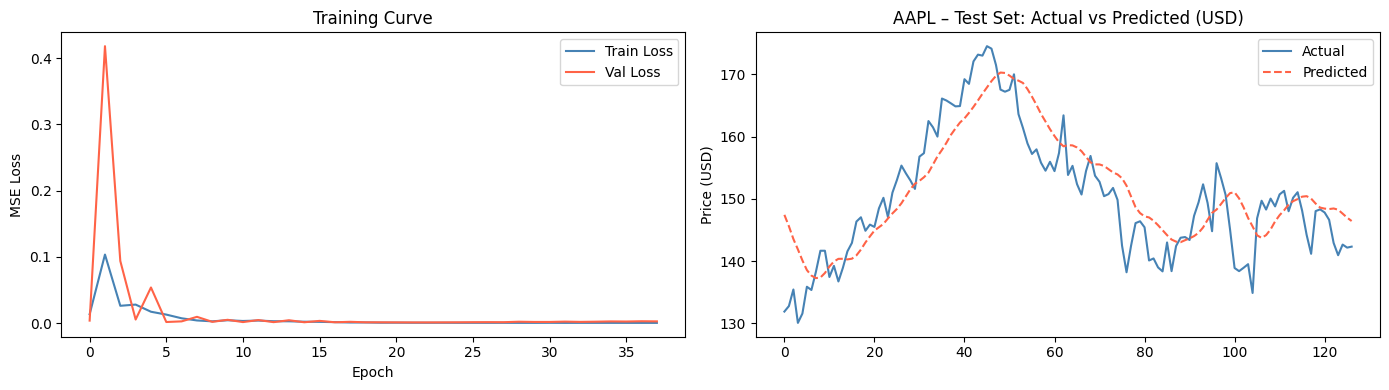

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Model
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=len(features),
                            hidden_size=128,
                            num_layers=2,
                            batch_first=True,
                            dropout=0.2)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

# Filter data from 2018
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df_recent = df[df['Date'] >= '2018-01-01'].reset_index(drop=True)
print(f"Rows: {len(df_recent)} | {df_recent['Date'].min()} → {df_recent['Date'].max()}")


features   = ['Open', 'High', 'Low', 'Close', 'Volume']
target_idx = features.index('Close')
WINDOW     = 60

data_raw  = df_recent[features].dropna().values.astype(np.float64)
n         = len(data_raw)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

# Scale data
scaler = MinMaxScaler()
all_sc = scaler.fit_transform(data_raw)

train_sc = all_sc[:train_end]
val_sc   = all_sc[train_end:val_end]
test_sc  = all_sc[val_end:]

# Sequences
def create_sequences(scaled, window, target_idx):
    X, y = [], []
    for i in range(window, len(scaled)):
        X.append(scaled[i - window : i])
        y.append(scaled[i, target_idx])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_sc, WINDOW, target_idx)
X_val,   y_val   = create_sequences(val_sc,   WINDOW, target_idx)
X_test,  y_test  = create_sequences(test_sc,  WINDOW, target_idx)

print(f"y_train: {y_train.min():.3f} → {y_train.max():.3f}")
print(f"y_val:   {y_val.min():.3f} → {y_val.max():.3f}")
print(f"y_test:  {y_test.min():.3f} → {y_test.max():.3f}")

# Time-Series Cross-Validation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

print("── Time-Series Cross-Validation (5-Fold) ──")

trainval_sc = all_sc[:val_end]
tscv        = TimeSeriesSplit(n_splits=5)
cv_maes     = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(trainval_sc)):
    # Split fold
    fold_tr = trainval_sc[tr_idx]
    fold_va = trainval_sc[va_idx]

    # Sequences
    Xf_tr, yf_tr = create_sequences(fold_tr, WINDOW, target_idx)
    Xf_va, yf_va = create_sequences(fold_va, WINDOW, target_idx)

    if len(Xf_tr) == 0 or len(Xf_va) == 0:
        print(f"  Fold {fold+1}: skip (not enough data)")
        continue

    # Train fresh model
    fm = LSTMModel()
    fm_opt  = torch.optim.Adam(fm.parameters(), lr=0.0005)
    fm_crit = nn.MSELoss()
    fm_loader = DataLoader(TensorDataset(
        torch.tensor(Xf_tr, dtype=torch.float32),
        torch.tensor(yf_tr, dtype=torch.float32)
    ), batch_size=32, shuffle=False)

    for epoch in range(20):  # ít epoch hơn để nhanh
        fm.train()
        for bX, by in fm_loader:
            fm_opt.zero_grad()
            fm_crit(fm(bX).squeeze(), by).backward()
            fm_opt.step()

    # Evaluate on fold val
    fm.eval()
    with torch.no_grad():
        fp = fm(torch.tensor(Xf_va, dtype=torch.float32)).squeeze().numpy()

    # Inverse transform
    def inv_fold(vals):
        dummy = np.zeros((len(vals), len(features)))
        dummy[:, target_idx] = vals
        return scaler.inverse_transform(dummy)[:, target_idx]

    mae = mean_absolute_error(inv_fold(yf_va), inv_fold(fp))
    print(f"  Fold {fold+1} | train: {len(Xf_tr)} | val: {len(Xf_va)} | MAE: ${mae:.2f}")
    cv_maes.append(mae)

print(f"\n  CV MAE: ${np.mean(cv_maes):.2f} ± ${np.std(cv_maes):.2f}")
print("  → Used to validate model stability before final training")

model     = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=False)

# Training
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

best_val_loss = float('inf')
patience, wait = 15, 0
best_weights   = None
train_losses, val_losses = [], []

for epoch in range(100):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_X).squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t).squeeze(), y_val_t).item()

    train_losses.append(epoch_loss / len(train_loader))
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | train: {epoch_loss/len(train_loader):.6f} | val: {val_loss:.6f}")

model.load_state_dict(best_weights)

# Inverse transform
def inverse_close(vals):
    dummy = np.zeros((len(vals), len(features)))
    dummy[:, target_idx] = vals
    return scaler.inverse_transform(dummy)[:, target_idx]

model.eval()
with torch.no_grad():
    preds_sc = model(X_test_t).squeeze().numpy()

preds_real  = inverse_close(preds_sc)
y_test_real = inverse_close(y_test)


# Metrics
mae  = mean_absolute_error(y_test_real, preds_real)
rmse = np.sqrt(mean_squared_error(y_test_real, preds_real))
mape = np.mean(np.abs((y_test_real - preds_real) / (y_test_real + 1e-8))) * 100

print(f"\nMAE  = ${mae:.2f}")
print(f"RMSE = ${rmse:.2f}")
print(f"MAPE = {mape:.2f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='tomato')
axes[0].set_title('Training Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(y_test_real,  label='Actual',    color='steelblue')
axes[1].plot(preds_real,   label='Predicted', color='tomato', linestyle='--')
axes[1].set_title('AAPL – Test Set: Actual vs Predicted (USD)')
axes[1].set_ylabel('Price (USD)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Check overfitting & accuracy
model.eval()
with torch.no_grad():
    # Predict both train & val for comparision
    preds_train_sc = model(X_train_t).squeeze().numpy()
    preds_val_sc   = model(X_val_t).squeeze().numpy()
    preds_test_sc  = model(X_test_t).squeeze().numpy()

preds_train = inverse_close(preds_train_sc)
preds_val   = inverse_close(preds_val_sc)
preds_test  = inverse_close(preds_test_sc)

true_train  = inverse_close(y_train)
true_val    = inverse_close(y_val)
true_test   = inverse_close(y_test)

def metrics(true, pred, label):
    mae  = mean_absolute_error(true, pred)
    rmse = np.sqrt(mean_squared_error(true, pred))
    mape = np.mean(np.abs((true - pred) / (true + 1e-8))) * 100
    print(f"[{label:>10}] MAE=${mae:6.2f} | RMSE=${rmse:6.2f} | MAPE={mape:5.2f}%")
    return mae, rmse, mape

print("── Accuracy trên từng split ──")
metrics(true_train, preds_train, "Train")
metrics(true_val,   preds_val,   "Val")
metrics(true_test,  preds_test,  "Test")

── Accuracy trên từng split ──
[     Train] MAE=$  2.81 | RMSE=$  3.50 | MAPE= 4.29%
[       Val] MAE=$  4.00 | RMSE=$  4.97 | MAPE= 2.47%
[      Test] MAE=$  4.62 | RMSE=$  5.60 | MAPE= 3.11%


(4.617573149954733,
 np.float64(5.596257292891509),
 np.float64(3.1116640902480666))

# TASK 1.2

Task 1.2 — N-th Day Forecast (K=1, 3, 7)
Objective: Predict the stock price exactly K days ahead (not next day).
Approach: Shift the target by K timesteps in create_sequences_kth(). Same LSTM architecture as Task 1.1, fresh model trained per K value.
Expected behavior: MAPE increases as K increases — predicting further into the future is harder.


Training K=1...
  K=1 | Early stop epoch 22

Training K=3...
  K=3 | Early stop epoch 22

Training K=7...
  K=7 | Early stop epoch 32

   K |      MAE |     RMSE |     MAPE
-------------------------------------
   1 | $   4.79 | $   5.69 |    3.22%
   3 | $   5.75 | $   6.89 |    3.86%
   7 | $   7.36 | $   8.46 |    4.88%


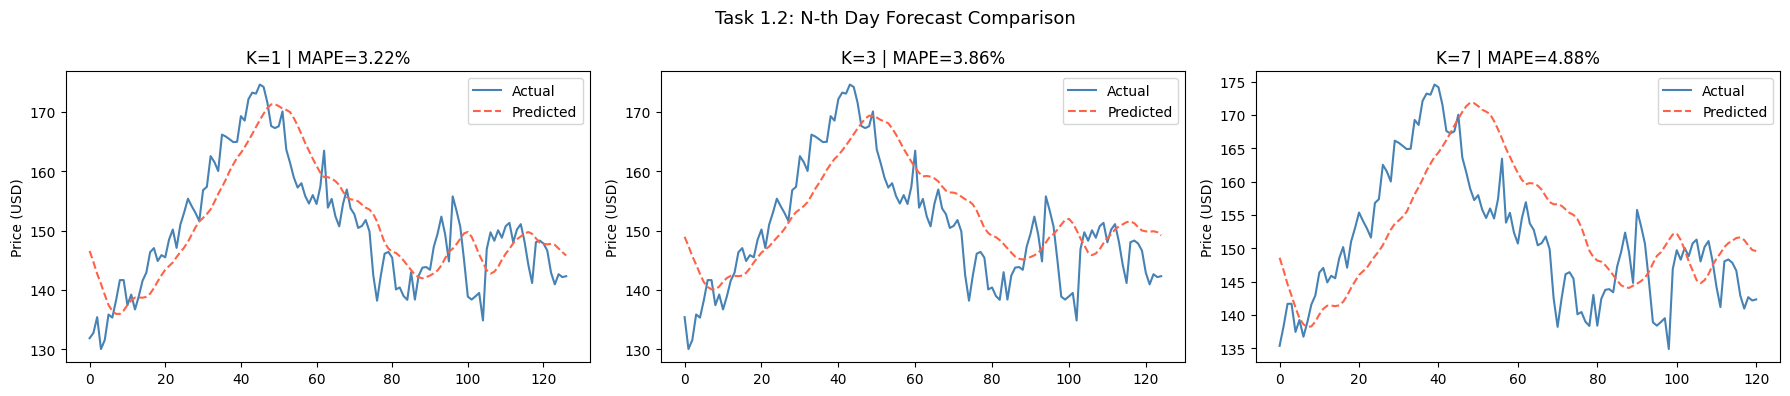

In [ ]:
# Task 1.2
import copy

def run_kth_forecast(train_sc, val_sc, test_sc, window, target_idx, k, epochs=100, patience=15):
    # Sequences
    def create_seq(scaled, w, ti, k):
        X, y = [], []
        for i in range(w, len(scaled) - k + 1):
            X.append(scaled[i - w : i])
            y.append(scaled[i + k - 1, ti])
        return np.array(X), np.array(y)

    X_tr, y_tr = create_seq(train_sc, window, target_idx, k)
    X_va, y_va = create_seq(val_sc,   window, target_idx, k)
    X_te, y_te = create_seq(test_sc,  window, target_idx, k)

    # Tensors
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_va_t = torch.tensor(X_va, dtype=torch.float32)
    y_va_t = torch.tensor(y_va, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=32, shuffle=False)

    # Fresh model
    m = LSTMModel()
    opt = torch.optim.Adam(m.parameters(), lr=0.0005)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        opt, mode='min', factor=0.5, patience=5)
    crit = nn.MSELoss()

    best_loss, wait = float('inf'), 0
    best_w = None

    for epoch in range(epochs):
        m.train()
        for bX, by in loader:
            opt.zero_grad()
            loss = crit(m(bX).squeeze(), by)
            loss.backward()
            opt.step()

        m.eval()
        with torch.no_grad():
            val_loss = crit(m(X_va_t).squeeze(), y_va_t).item()
        scheduler.step(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            best_w = {k2: v.clone() for k2, v in m.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  K={k} | Early stop epoch {epoch}")
                break

    m.load_state_dict(best_w)

    # Predict & inverse
    m.eval()
    with torch.no_grad():
        preds_sc = m(X_te_t).squeeze().numpy()

    def inv(vals):
        dummy = np.zeros((len(vals), len(features)))
        dummy[:, target_idx] = vals
        return scaler.inverse_transform(dummy)[:, target_idx]

    preds_real = inv(preds_sc)
    true_real  = inv(y_te)

    mae  = mean_absolute_error(true_real, preds_real)
    rmse = np.sqrt(mean_squared_error(true_real, preds_real))
    mape = np.mean(np.abs((true_real - preds_real) / (true_real + 1e-8))) * 100

    return preds_real, true_real, mae, rmse, mape


# Run all 3 K
results = {}
for K in [1, 3, 7]:
    print(f"\nTraining K={K}...")
    preds, trues, mae, rmse, mape = run_kth_forecast(
        train_sc, val_sc, test_sc, WINDOW, target_idx, K
    )
    results[K] = {'preds': preds, 'trues': trues,
                  'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Metrics table
print(f"\n{'K':>4} | {'MAE':>8} | {'RMSE':>8} | {'MAPE':>8}")
print("-" * 37)
for k, m in results.items():
    print(f"{k:>4} | ${m['MAE']:>7.2f} | ${m['RMSE']:>7.2f} | {m['MAPE']:>7.2f}%")

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, K in enumerate([1, 3, 7]):
    axes[i].plot(results[K]['trues'], label='Actual',    color='steelblue')
    axes[i].plot(results[K]['preds'], label='Predicted', color='tomato', linestyle='--')
    axes[i].set_title(f'K={K} | MAPE={results[K]["MAPE"]:.2f}%')
    axes[i].set_ylabel('Price (USD)')
    axes[i].legend()
plt.suptitle('Task 1.2: N-th Day Forecast Comparison', fontsize=13)
plt.tight_layout()
plt.show()

# TASK 1.3

Task 1.3 — K Consecutive Days Forecast (K=3, 7)
Objective: Predict K consecutive days simultaneously (multi-output).
Approach: Change output layer to Dense(K) — model outputs all K days at once. Target shape becomes (N, K) instead of (N,).
Note: Multi-step predictions are smoother than actual prices — this is expected behavior as the model learns the trend rather than individual price movements.


Training K=3 consecutive days...
  X_train: (810, 60, 5) | y_train: (810, 3)
  Epoch   0 | train: 0.014266 | val: 0.010182
  Epoch  10 | train: 0.002484 | val: 0.001756
  Epoch  20 | train: 0.000725 | val: 0.003086
  K=3 | Early stop epoch 30
    Day |      MAE |     MAPE
  ---------------------------
      1 | $   5.07 |    3.42%
      2 | $   5.60 |    3.77%
      3 | $   6.13 |    4.13%

Training K=7 consecutive days...
  X_train: (806, 60, 5) | y_train: (806, 7)
  Epoch   0 | train: 0.030172 | val: 0.031884
  Epoch  10 | train: 0.001269 | val: 0.025394
  Epoch  20 | train: 0.000961 | val: 0.020768
  K=7 | Early stop epoch 21
    Day |      MAE |     MAPE
  ---------------------------
      1 | $   6.28 |    4.25%
      2 | $   6.52 |    4.41%
      3 | $   6.33 |    4.22%
      4 | $   6.78 |    4.55%
      5 | $   6.54 |    4.32%
      6 | $   6.95 |    4.61%
      7 | $   7.31 |    4.87%

   K |      MAE |     RMSE |     MAPE
-------------------------------------
   3 | $   5.60

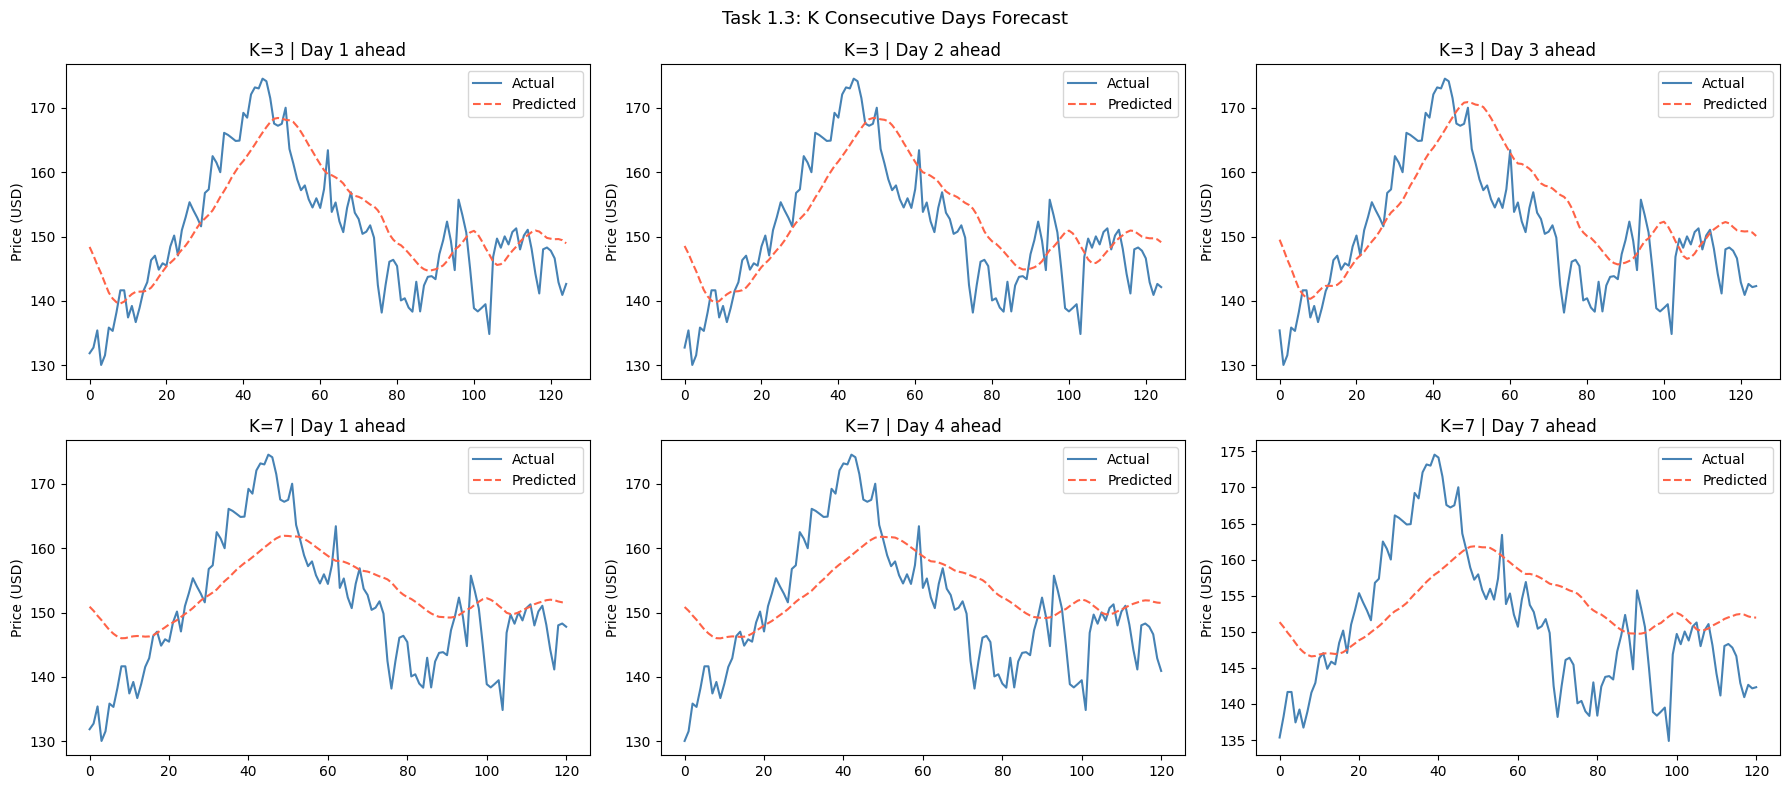

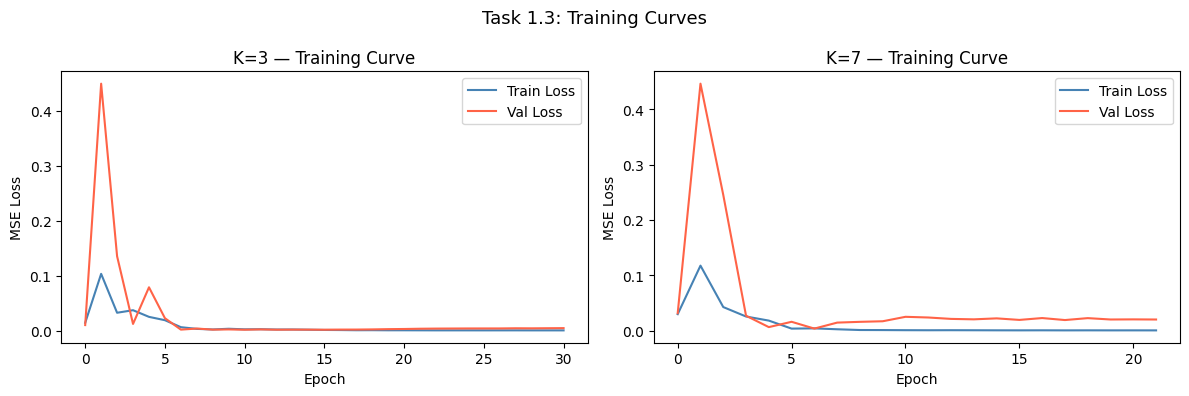

In [ ]:
# TASK 1.3

def run_multi_forecast(train_sc, val_sc, test_sc, window, target_idx, k, epochs=100, patience=15):

    # Sequences — y shape: (N, k)
    def create_seq_multi(scaled, w, ti, k):
        X, y = [], []
        for i in range(w, len(scaled) - k + 1):
            X.append(scaled[i - w : i])
            y.append(scaled[i : i + k, ti])
        return np.array(X), np.array(y)

    X_tr, y_tr = create_seq_multi(train_sc, window, target_idx, k)
    X_va, y_va = create_seq_multi(val_sc,   window, target_idx, k)
    X_te, y_te = create_seq_multi(test_sc,  window, target_idx, k)
    print(f"  X_train: {X_tr.shape} | y_train: {y_tr.shape}")

    # Tensors
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)
    X_va_t = torch.tensor(X_va, dtype=torch.float32)
    y_va_t = torch.tensor(y_va, dtype=torch.float32)
    X_te_t = torch.tensor(X_te, dtype=torch.float32)

    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=32, shuffle=False)

    # Model — output k nodes thay vì 1
    class LSTMMultiStep(nn.Module):
        def __init__(self):
            super().__init__()
            self.lstm = nn.LSTM(input_size=len(features),
                                hidden_size=128,
                                num_layers=2,
                                batch_first=True,
                                dropout=0.2)
            self.fc = nn.Linear(128, k)

        def forward(self, x):
            out, _ = self.lstm(x)
            return self.fc(out[:, -1, :])  # shape: (batch, k)

    m   = LSTMMultiStep()
    opt = torch.optim.Adam(m.parameters(), lr=0.0005)
    sch = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode='min', factor=0.5, patience=5)
    crit = nn.MSELoss()

    best_loss, wait, best_w = float('inf'), 0, None
    train_losses, val_losses = [], []

    for epoch in range(epochs):
        m.train()
        epoch_loss = 0
        for bX, by in loader:
            opt.zero_grad()
            loss = crit(m(bX), by)   # không squeeze vì y shape (batch, k)
            loss.backward()
            opt.step()
            epoch_loss += loss.item()

        m.eval()
        with torch.no_grad():
            val_loss = crit(m(X_va_t), y_va_t).item()

        sch.step(val_loss)
        train_losses.append(epoch_loss / len(loader))
        val_losses.append(val_loss)

        if val_loss < best_loss:
            best_loss = val_loss
            best_w    = {k2: v.clone() for k2, v in m.state_dict().items()}
            wait      = 0
        else:
            wait += 1
            if wait >= patience:
                print(f"  K={k} | Early stop epoch {epoch}")
                break

        if epoch % 10 == 0:
            print(f"  Epoch {epoch:3d} | train: {epoch_loss/len(loader):.6f} | val: {val_loss:.6f}")

    m.load_state_dict(best_w)

    # Predict
    m.eval()
    with torch.no_grad():
        preds_sc = m(X_te_t).numpy()  # shape: (N, k)

    # Inverse transform each day
    def inv_multi(arr_2d):
        result = np.zeros_like(arr_2d)
        for day in range(arr_2d.shape[1]):
            dummy = np.zeros((len(arr_2d), len(features)))
            dummy[:, target_idx] = arr_2d[:, day]
            result[:, day] = scaler.inverse_transform(dummy)[:, target_idx]
        return result

    preds_real = inv_multi(preds_sc)
    true_real  = inv_multi(y_te)

    # Overall metrics
    mae  = mean_absolute_error(true_real.flatten(), preds_real.flatten())
    rmse = np.sqrt(mean_squared_error(true_real.flatten(), preds_real.flatten()))
    mape = np.mean(np.abs((true_real - preds_real) / (true_real + 1e-8))) * 100

    # Per-day metrics
    print(f"  {'Day':>5} | {'MAE':>8} | {'MAPE':>8}")
    print(f"  {'-'*27}")
    for day in range(k):
        d_mae  = mean_absolute_error(true_real[:, day], preds_real[:, day])
        d_mape = np.mean(np.abs((true_real[:, day] - preds_real[:, day])
                                 / (true_real[:, day] + 1e-8))) * 100
        print(f"  {day+1:>5} | ${d_mae:>7.2f} | {d_mape:>7.2f}%")

    return preds_real, true_real, mae, rmse, mape, train_losses, val_losses


# Run K=3 and K=7
results_13 = {}
for K in [3, 7]:
    print(f"\nTraining K={K} consecutive days...")
    preds, trues, mae, rmse, mape, tl, vl = run_multi_forecast(
        train_sc, val_sc, test_sc, WINDOW, target_idx, K
    )
    results_13[K] = {'preds': preds, 'trues': trues,
                     'train_losses': tl, 'val_losses': vl,
                     'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# Summary table
print(f"\n{'K':>4} | {'MAE':>8} | {'RMSE':>8} | {'MAPE':>8}")
print("-" * 37)
for k, m in results_13.items():
    print(f"{k:>4} | ${m['MAE']:>7.2f} | ${m['RMSE']:>7.2f} | {m['MAPE']:>7.2f}%")

# Plot predictions
fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for row, K in enumerate([3, 7]):
    trues = results_13[K]['trues']
    preds = results_13[K]['preds']
    for col, day in enumerate([0, K//2, K-1]):
        axes[row, col].plot(trues[:, day], label='Actual',    color='steelblue')
        axes[row, col].plot(preds[:, day], label='Predicted', color='tomato', linestyle='--')
        axes[row, col].set_title(f'K={K} | Day {day+1} ahead')
        axes[row, col].set_ylabel('Price (USD)')
        axes[row, col].legend()
plt.suptitle('Task 1.3: K Consecutive Days Forecast', fontsize=13)
plt.tight_layout()
plt.show()

# Plot training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, K in enumerate([3, 7]):
    axes[i].plot(results_13[K]['train_losses'], label='Train Loss', color='steelblue')
    axes[i].plot(results_13[K]['val_losses'],   label='Val Loss',   color='tomato')
    axes[i].set_title(f'K={K} — Training Curve')
    axes[i].set_xlabel('Epoch')
    axes[i].set_ylabel('MSE Loss')
    axes[i].legend()
plt.suptitle('Task 1.3: Training Curves', fontsize=13)
plt.tight_layout()
plt.show()

Task 2: Vietnam Stock Price Prediction (FPT)
Data Preparation

Dataset: FPT Corporation historical data (VNINDEX, 2018–2023), 1,287 rows
Features: Open, High, Low, Close, Volume
Split: 70% / 15% / 15% chronological
Date filter: 2018 onwards — reduces price range disparity (FPT increased ~4x from 2018 vs ~10x from 2006)
Currency: Vietnamese Dong (VND) — MAE reported in VND

# TASK 2.1

Task 2.1 — Multi-Feature Next-Day Prediction
Same LSTM architecture as Task 1.1, applied to FPT data.
5-fold TimeSeriesSplit CV performed on train+val before final training.

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler

# Load & sort
df = pd.read_csv("/content/FPT-VNINDEX-History.csv")
print(df.head())
print(df.columns)

# Sort chronologically
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date').reset_index(drop=True)
    print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

print(f"Total rows: {len(df)}")

# Config
features   = ['Open', 'High', 'Low', 'Close', 'Volume']
target_idx = features.index('Close')  # = 3
WINDOW     = 60

# Chronological split
data_raw  = df[features].dropna().values.astype(np.float64)
n         = len(data_raw)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train_raw = data_raw[:train_end]
val_raw   = data_raw[train_end:val_end]
test_raw  = data_raw[val_end:]
print(f"Train: {len(train_raw)} | Val: {len(val_raw)} | Test: {len(test_raw)}")

# Scale — fit only on train
scaler   = MinMaxScaler()
scaler.fit(train_raw)
train_sc = scaler.transform(train_raw)
val_sc   = scaler.transform(val_raw)
test_sc  = scaler.transform(test_raw)

print(f"y_train: {train_sc[:, target_idx].min():.3f} → {train_sc[:, target_idx].max():.3f}")
print(f"y_val:   {val_sc[:, target_idx].min():.3f} → {val_sc[:, target_idx].max():.3f}")
print(f"y_test:  {test_sc[:, target_idx].min():.3f} → {test_sc[:, target_idx].max():.3f}")

# Sequences
def create_sequences(scaled, window, target_idx):
    X, y = [], []
    for i in range(window, len(scaled)):
        X.append(scaled[i - window : i])
        y.append(scaled[i, target_idx])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_sc, WINDOW, target_idx)
X_val,   y_val   = create_sequences(val_sc,   WINDOW, target_idx)
X_test,  y_test  = create_sequences(test_sc,  WINDOW, target_idx)

print(f"\nX_train: {X_train.shape} | y range: {y_train.min():.3f}→{y_train.max():.3f}")
print(f"X_val:   {X_val.shape}   | y range: {y_val.min():.3f}→{y_val.max():.3f}")
print(f"X_test:  {X_test.shape}  | y range: {y_test.min():.3f}→{y_test.max():.3f}")

   Unnamed: 0     Open     High      Low    Close  Volume TradingDate
0           0  15710.0  15710.0  15710.0  15710.0   83530  2006-12-13
1           1  16495.0  16495.0  16495.0  16495.0  280710  2006-12-14
2           2  17320.0  17320.0  17320.0  17320.0  265300  2006-12-15
3           3  18184.0  18184.0  18184.0  18184.0  215790  2006-12-18
4           4  19087.0  19087.0  19087.0  19087.0  137520  2006-12-19
Index(['Unnamed: 0', 'Open', 'High', 'Low', 'Close', 'Volume', 'TradingDate'], dtype='object')
Total rows: 4038
Train: 2826 | Val: 606 | Test: 606
y_train: 0.000 → 1.000
y_val:   0.676 → 1.354
y_test:  1.317 → 3.814

X_train: (2766, 60, 5) | y range: 0.000→1.000
X_val:   (546, 60, 5)   | y range: 0.734→1.354
X_test:  (546, 60, 5)  | y range: 1.504→3.814


In [ ]:
# Filter from 2018 ->
df['TradingDate'] = pd.to_datetime(df['TradingDate'])
df_recent = df[df['TradingDate'] >= '2018-01-01'].reset_index(drop=True)
print(f"Rows after 2015: {len(df_recent)} | {df_recent['TradingDate'].min().date()} → {df_recent['TradingDate'].max().date()}")

data_raw  = df_recent[features].dropna().values.astype(np.float64)
n         = len(data_raw)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

scaler = MinMaxScaler()
all_sc = scaler.fit_transform(data_raw)

train_sc = all_sc[:train_end]
val_sc   = all_sc[train_end:val_end]
test_sc  = all_sc[val_end:]

X_train, y_train = create_sequences(train_sc, WINDOW, target_idx)
X_val,   y_val   = create_sequences(val_sc,   WINDOW, target_idx)
X_test,  y_test  = create_sequences(test_sc,  WINDOW, target_idx)

print(f"y_train: {y_train.min():.3f} → {y_train.max():.3f}")
print(f"y_val:   {y_val.min():.3f} → {y_val.max():.3f}")
print(f"y_test:  {y_test.min():.3f} → {y_test.max():.3f}")

Rows after 2015: 1287 | 2018-01-02 → 2023-02-28
y_train: 0.000 → 0.784
y_val:   0.663 → 1.000
y_test:  0.614 → 0.904


y_train: 0.000 → 0.784
y_val:   0.663 → 1.000
y_test:  0.614 → 0.904
── Time-Series Cross-Validation (5-Fold) ──
  Fold 1 | train: 123 | val: 122 | MAE: $1219.43
  Fold 2 | train: 305 | val: 122 | MAE: $1509.70
  Fold 3 | train: 487 | val: 122 | MAE: $859.80
  Fold 4 | train: 669 | val: 122 | MAE: $1484.40
  Fold 5 | train: 851 | val: 122 | MAE: $2206.86

  CV MAE: $1456.04 ± $442.47
  → Used to validate model stability before final training
Epoch   0 | train: 0.018485 | val: 0.138925
Epoch   5 | train: 0.019101 | val: 0.131182
Epoch  10 | train: 0.002568 | val: 0.003251
Epoch  15 | train: 0.000684 | val: 0.002070
Epoch  20 | train: 0.003829 | val: 0.003131
Epoch  25 | train: 0.003855 | val: 0.013478
Early stopping at epoch 28

MAE  = $1742.86
RMSE = $2308.49
MAPE = 2.24%


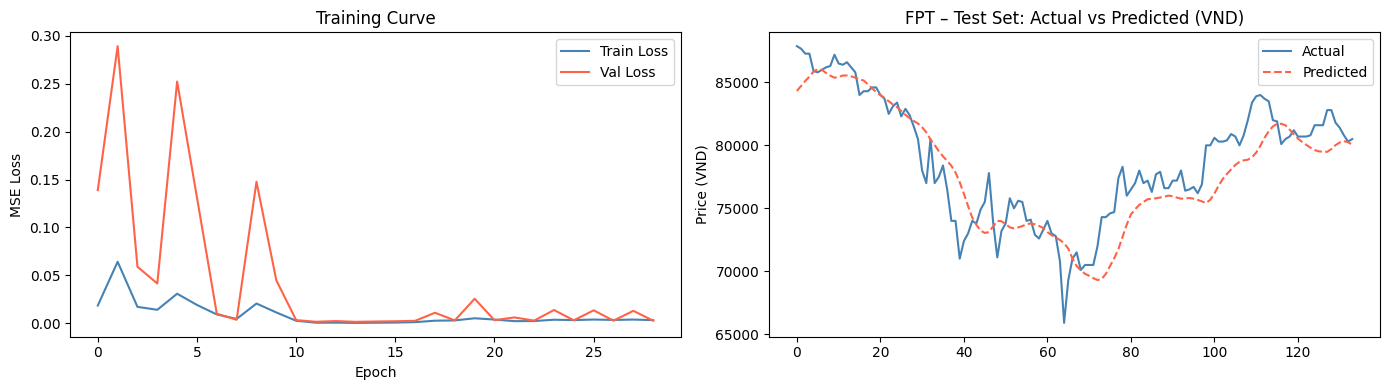

In [ ]:
features   = ['Open', 'High', 'Low', 'Close', 'Volume']
target_idx = features.index('Close')
WINDOW     = 60

data_raw  = df_recent[features].dropna().values.astype(np.float64)
n         = len(data_raw)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

# Scale
scaler = MinMaxScaler()
all_sc = scaler.fit_transform(data_raw)

train_sc = all_sc[:train_end]
val_sc   = all_sc[train_end:val_end]
test_sc  = all_sc[val_end:]

# Sequences
def create_sequences(scaled, window, target_idx):
    X, y = [], []
    for i in range(window, len(scaled)):
        X.append(scaled[i - window : i])
        y.append(scaled[i, target_idx])
    return np.array(X), np.array(y)

X_train, y_train = create_sequences(train_sc, WINDOW, target_idx)
X_val,   y_val   = create_sequences(val_sc,   WINDOW, target_idx)
X_test,  y_test  = create_sequences(test_sc,  WINDOW, target_idx)

print(f"y_train: {y_train.min():.3f} → {y_train.max():.3f}")
print(f"y_val:   {y_val.min():.3f} → {y_val.max():.3f}")
print(f"y_test:  {y_test.min():.3f} → {y_test.max():.3f}")


# Time-Series Cross-Validation
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error

print("── Time-Series Cross-Validation (5-Fold) ──")

trainval_sc = all_sc[:val_end]
tscv        = TimeSeriesSplit(n_splits=5)
cv_maes     = []

for fold, (tr_idx, va_idx) in enumerate(tscv.split(trainval_sc)):
    # Split fold
    fold_tr = trainval_sc[tr_idx]
    fold_va = trainval_sc[va_idx]

    # Sequences
    Xf_tr, yf_tr = create_sequences(fold_tr, WINDOW, target_idx)
    Xf_va, yf_va = create_sequences(fold_va, WINDOW, target_idx)

    if len(Xf_tr) == 0 or len(Xf_va) == 0:
        print(f"  Fold {fold+1}: skip (not enough data)")
        continue

    # Train fresh model
    fm = LSTMModel()
    fm_opt  = torch.optim.Adam(fm.parameters(), lr=0.0005)
    fm_crit = nn.MSELoss()
    fm_loader = DataLoader(TensorDataset(
        torch.tensor(Xf_tr, dtype=torch.float32),
        torch.tensor(yf_tr, dtype=torch.float32)
    ), batch_size=32, shuffle=False)

    for epoch in range(20):
        fm.train()
        for bX, by in fm_loader:
            fm_opt.zero_grad()
            fm_crit(fm(bX).squeeze(), by).backward()
            fm_opt.step()

    # Evaluate on fold val
    fm.eval()
    with torch.no_grad():
        fp = fm(torch.tensor(Xf_va, dtype=torch.float32)).squeeze().numpy()

    # Inverse transform
    def inv_fold(vals):
        dummy = np.zeros((len(vals), len(features)))
        dummy[:, target_idx] = vals
        return scaler.inverse_transform(dummy)[:, target_idx]

    mae = mean_absolute_error(inv_fold(yf_va), inv_fold(fp))
    print(f"  Fold {fold+1} | train: {len(Xf_tr)} | val: {len(Xf_va)} | MAE: ${mae:.2f}")
    cv_maes.append(mae)

print(f"\n  CV MAE: ${np.mean(cv_maes):.2f} ± ${np.std(cv_maes):.2f}")
print("  → Used to validate model stability before final training")

# Model
class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=len(features),
                            hidden_size=128,
                            num_layers=2,
                            batch_first=True,
                            dropout=0.2)
        self.fc = nn.Linear(128, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

model     = LSTMModel()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4)

X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
y_val_t   = torch.tensor(y_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=32, shuffle=False)

# Train
best_val_loss = float('inf')
patience, wait = 15, 0
best_weights   = None
train_losses, val_losses = [], []

for epoch in range(100):
    model.train()
    epoch_loss = 0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(batch_X).squeeze(), batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()

    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_t).squeeze(), y_val_t).item()

    train_losses.append(epoch_loss / len(train_loader))
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_weights  = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 5 == 0:
        print(f"Epoch {epoch:3d} | train: {epoch_loss/len(train_loader):.6f} | val: {val_loss:.6f}")

model.load_state_dict(best_weights)

# Inverse transform
def inverse_close(vals):
    dummy = np.zeros((len(vals), len(features)))
    dummy[:, target_idx] = vals
    return scaler.inverse_transform(dummy)[:, target_idx]

model.eval()
with torch.no_grad():
    preds_sc = model(X_test_t).squeeze().numpy()

preds_real  = inverse_close(preds_sc)
y_test_real = inverse_close(y_test)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# Metrics
mae  = mean_absolute_error(y_test_real, preds_real)
rmse = np.sqrt(mean_squared_error(y_test_real, preds_real))
mape = np.mean(np.abs((y_test_real - preds_real) / (y_test_real + 1e-8))) * 100

print(f"\nMAE  = ${mae:.2f}")
print(f"RMSE = ${rmse:.2f}")
print(f"MAPE = {mape:.2f}%")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(train_losses, label='Train Loss', color='steelblue')
axes[0].plot(val_losses,   label='Val Loss',   color='tomato')
axes[0].set_title('Training Curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE Loss')
axes[0].legend()

axes[1].plot(y_test_real,  label='Actual',    color='steelblue')
axes[1].plot(preds_real,   label='Predicted', color='tomato', linestyle='--')
axes[1].set_title('FPT – Test Set: Actual vs Predicted (VND)')
axes[1].set_ylabel('Price (VND)')
axes[1].legend()

plt.tight_layout()
plt.show()

# TASK 2.2

Task 2.2 — Vietnam N-th Day Forecast (K=1, 3, 7)
Same approach as Task 1.2, applied to FPT data. Uses run_kth_forecast() function defined in Task 1.2.

TASK 2.2 — FPT N-th Day Forecast (K=1, 3, 7)

Training K=1...
  K=1 | Early stop epoch 40

Training K=3...
  K=3 | Early stop epoch 71

Training K=7...
  K=7 | Early stop epoch 20

   K |          MAE |         RMSE |     MAPE
---------------------------------------------
   1 |      1,715 VND |      2,217 VND |    2.21%
   3 |      1,858 VND |      2,483 VND |    2.39%
   7 |      3,180 VND |      4,014 VND |    4.09%


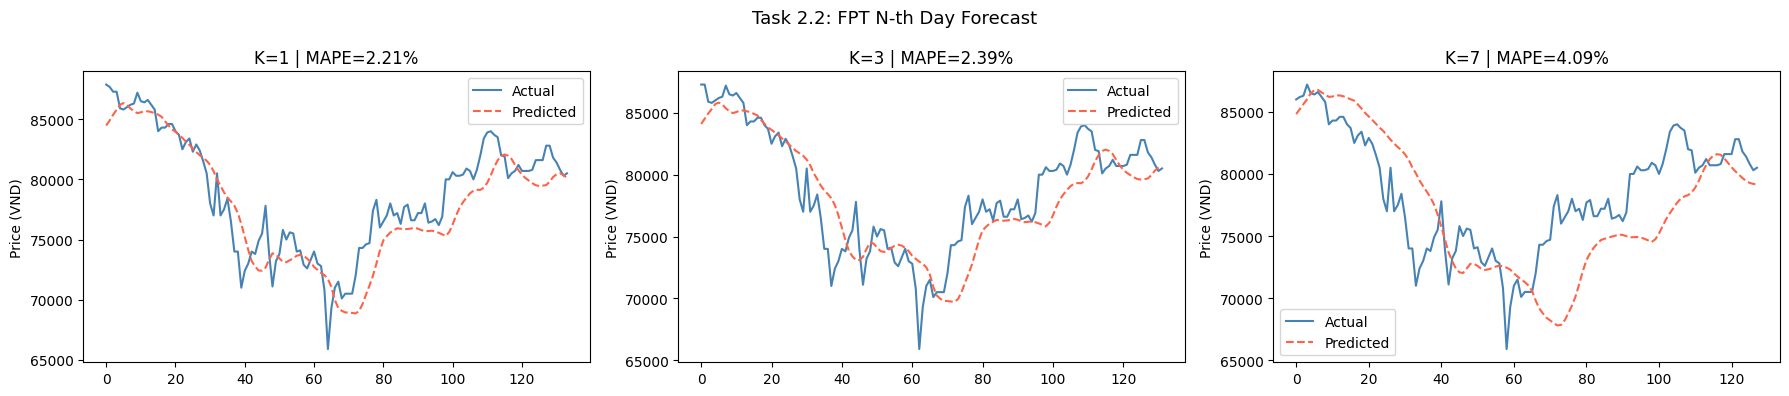

In [ ]:
# Task 2.2
print("="*55)
print("TASK 2.2 — FPT N-th Day Forecast (K=1, 3, 7)")
print("="*55)

results_22 = {}
for K in [1, 3, 7]:
    print(f"\nTraining K={K}...")
    preds, trues, mae, rmse, mape = run_kth_forecast(
        train_sc, val_sc, test_sc, WINDOW, target_idx, K
    )
    results_22[K] = {'preds': preds, 'trues': trues,
                     'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print(f"\n{'K':>4} | {'MAE':>12} | {'RMSE':>12} | {'MAPE':>8}")
print("-" * 45)
for k, m in results_22.items():
    print(f"{k:>4} | {m['MAE']:>10,.0f} VND | {m['RMSE']:>10,.0f} VND | {m['MAPE']:>7.2f}%")

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
for i, K in enumerate([1, 3, 7]):
    axes[i].plot(results_22[K]['trues'], label='Actual',    color='steelblue')
    axes[i].plot(results_22[K]['preds'], label='Predicted', color='tomato', linestyle='--')
    axes[i].set_title(f'K={K} | MAPE={results_22[K]["MAPE"]:.2f}%')
    axes[i].set_ylabel('Price (VND)')
    axes[i].legend()
plt.suptitle('Task 2.2: FPT N-th Day Forecast', fontsize=13)
plt.tight_layout()
plt.show()


# TASK 2.3

Task 2.3 — Vietnam K Consecutive Days Forecast (K=3, 7)
Same approach as Task 1.3, applied to FPT data. Uses run_multi_forecast() function defined in Task 1.3.

TASK 2.3 — FPT K Consecutive Days (K=3, 7)

Training K=3 consecutive days...
  X_train: (838, 60, 5) | y_train: (838, 3)
  Epoch   0 | train: 0.014404 | val: 0.032326
  Epoch  10 | train: 0.002232 | val: 0.005335
  Epoch  20 | train: 0.001996 | val: 0.002611
  Epoch  30 | train: 0.000931 | val: 0.001733
  Epoch  40 | train: 0.001409 | val: 0.001844
  Epoch  50 | train: 0.000388 | val: 0.001516
  Epoch  60 | train: 0.000379 | val: 0.001477
  Epoch  70 | train: 0.000346 | val: 0.001523
  K=3 | Early stop epoch 75
    Day |      MAE |     MAPE
  ---------------------------
      1 | $1829.15 |    2.32%
      2 | $1754.33 |    2.26%
      3 | $1819.13 |    2.36%

Training K=7 consecutive days...
  X_train: (834, 60, 5) | y_train: (834, 7)
  Epoch   0 | train: 0.005715 | val: 0.023390
  Epoch  10 | train: 0.003665 | val: 0.003732
  Epoch  20 | train: 0.000719 | val: 0.003850
  Epoch  30 | train: 0.000531 | val: 0.002778
  Epoch  40 | train: 0.000500 | val: 0.002858
  Epoch  50 | train: 0.00

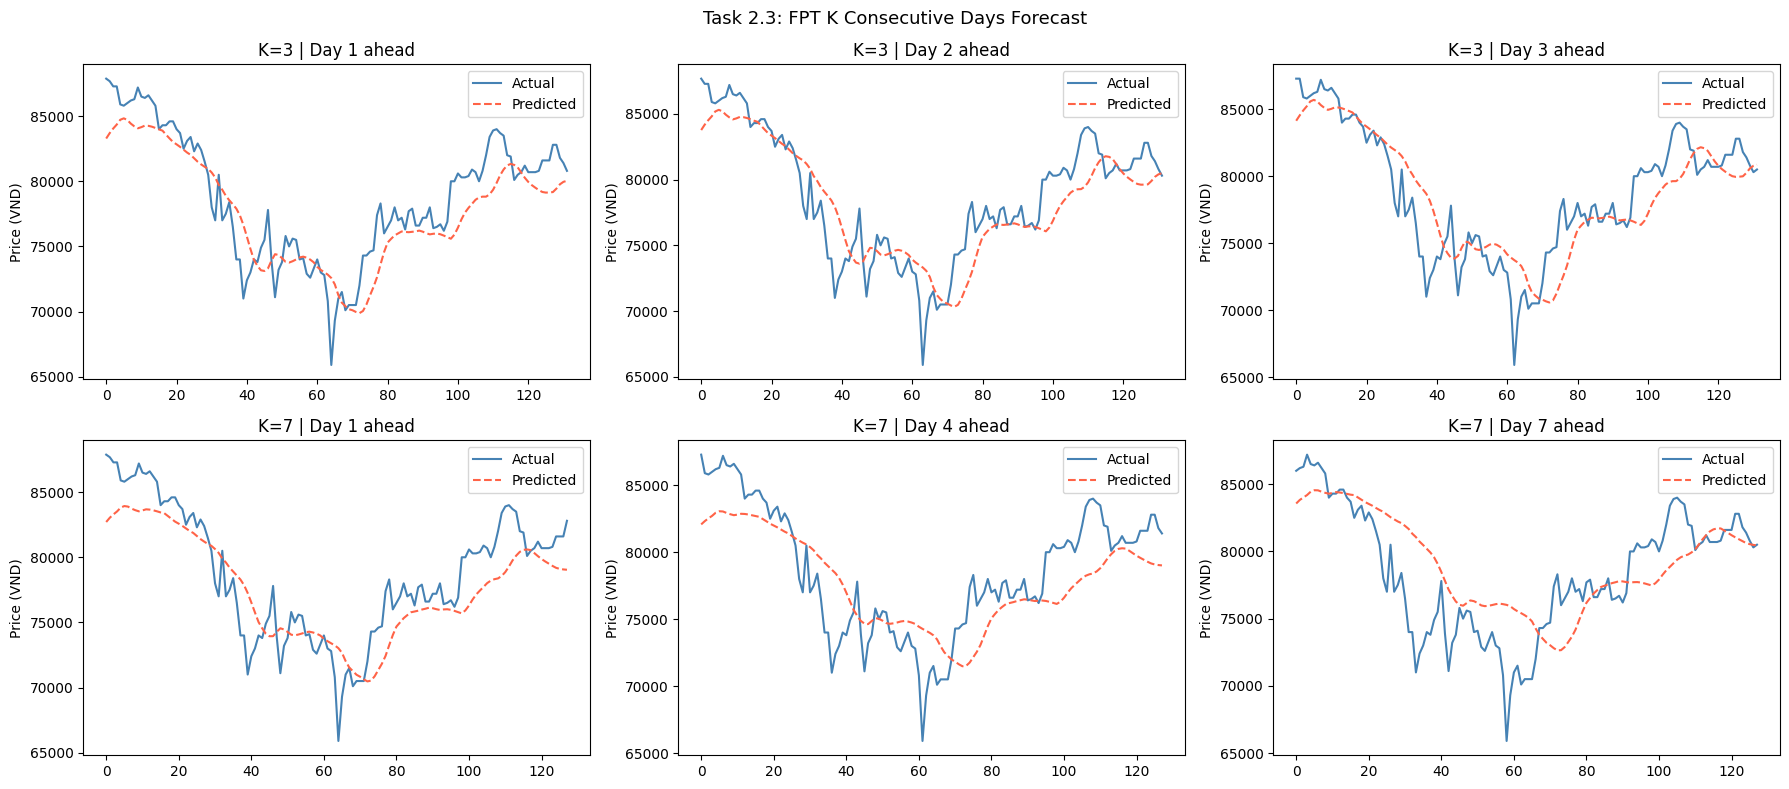

In [ ]:
# Task 2.3
print("="*55)
print("TASK 2.3 — FPT K Consecutive Days (K=3, 7)")
print("="*55)

results_23 = {}
for K in [3, 7]:
    print(f"\nTraining K={K} consecutive days...")
    preds, trues, mae, rmse, mape, tl, vl = run_multi_forecast(
        train_sc, val_sc, test_sc, WINDOW, target_idx, K
    )
    results_23[K] = {'preds': preds, 'trues': trues,
                     'train_losses': tl, 'val_losses': vl,
                     'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

print(f"\n{'K':>4} | {'MAE':>12} | {'RMSE':>12} | {'MAPE':>8}")
print("-" * 45)
for k, m in results_23.items():
    print(f"{k:>4} | {m['MAE']:>10,.0f} VND | {m['RMSE']:>10,.0f} VND | {m['MAPE']:>7.2f}%")

fig, axes = plt.subplots(2, 3, figsize=(18, 8))
for row, K in enumerate([3, 7]):
    for col, day in enumerate([0, K//2, K-1]):
        axes[row, col].plot(results_23[K]['trues'][:, day], label='Actual',    color='steelblue')
        axes[row, col].plot(results_23[K]['preds'][:, day], label='Predicted', color='tomato', linestyle='--')
        axes[row, col].set_title(f'K={K} | Day {day+1} ahead')
        axes[row, col].set_ylabel('Price (VND)')
        axes[row, col].legend()
plt.suptitle('Task 2.3: FPT K Consecutive Days Forecast', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Reset to original dataset
df_all = pd.read_csv("/content/FPT-VNINDEX-History.csv")
df_all['TradingDate'] = pd.to_datetime(df_all['TradingDate'])
df_all = df_all.sort_values('TradingDate').reset_index(drop=True)

print(f"Full data: {len(df_all)} rows | {df_all['TradingDate'].min().date()} → {df_all['TradingDate'].max().date()}")

df_feat_all = add_technical_indicators(df_all)
df_feat_all['buy_label'], df_feat_all['sell_label'] = create_labels(
    df_feat_all, HORIZON, THRESHOLD
)
df_feat_all = df_feat_all.dropna().reset_index(drop=True)

print(f"After processing: {len(df_feat_all)} rows")
print(f"Buy  signal: {df_feat_all['buy_label'].mean()*100:.1f}%")
print(f"Sell signal: {df_feat_all['sell_label'].mean()*100:.1f}%")

Full data: 4038 rows | 2006-12-13 → 2023-02-28
After processing: 4019 rows
Buy  signal: 35.7%
Sell signal: 31.7%


# TASK 3

Task 3: Trading Signal Identification (FPT)
Problem Formulation

Buy signal (Task 3.1): Price rises > 1% within 3 days → label = 1
Sell signal (Task 3.2): Price drops > 1% within 3 days → label = 1
Horizon: 3 days ahead
Threshold: 1% (chosen based on FPT daily return std = 1.79%)



Rows: 4017
Buy  signal: 29.6%
Sell signal: 25.5%

Buy  — train: 784 / 2751 (28.5%)
Sell — train: 735 / 2751 (26.7%)

── Training Buy Signal LSTM ──
  Epoch   0 | val F1: 0.0000 | lr: 3.00e-04
  Epoch  10 | val F1: 0.4085 | lr: 2.87e-04
  Early stop at epoch 17 | best F1: 0.4540

── Training Sell Signal LSTM ──
  Epoch   0 | val F1: 0.0592 | lr: 3.00e-04
  Epoch  10 | val F1: 0.2934 | lr: 2.87e-04
  Early stop at epoch 14 | best F1: 0.3195
── Training GradientBoosting ──
  Buy : best n_estimators = 485 | val F1 = 0.2680
  Sell: best n_estimators = 354 | val F1 = 0.2009

TASK 3.1 — Buy Signal
              precision    recall  f1-score   support

   No Signal       0.70      0.78      0.74       415
  Buy Signal       0.35      0.26      0.29       188

    accuracy                           0.62       603
   macro avg       0.52      0.52      0.52       603
weighted avg       0.59      0.62      0.60       603

TASK 3.2 — Sell Signal
              precision    recall  f1-score   suppor

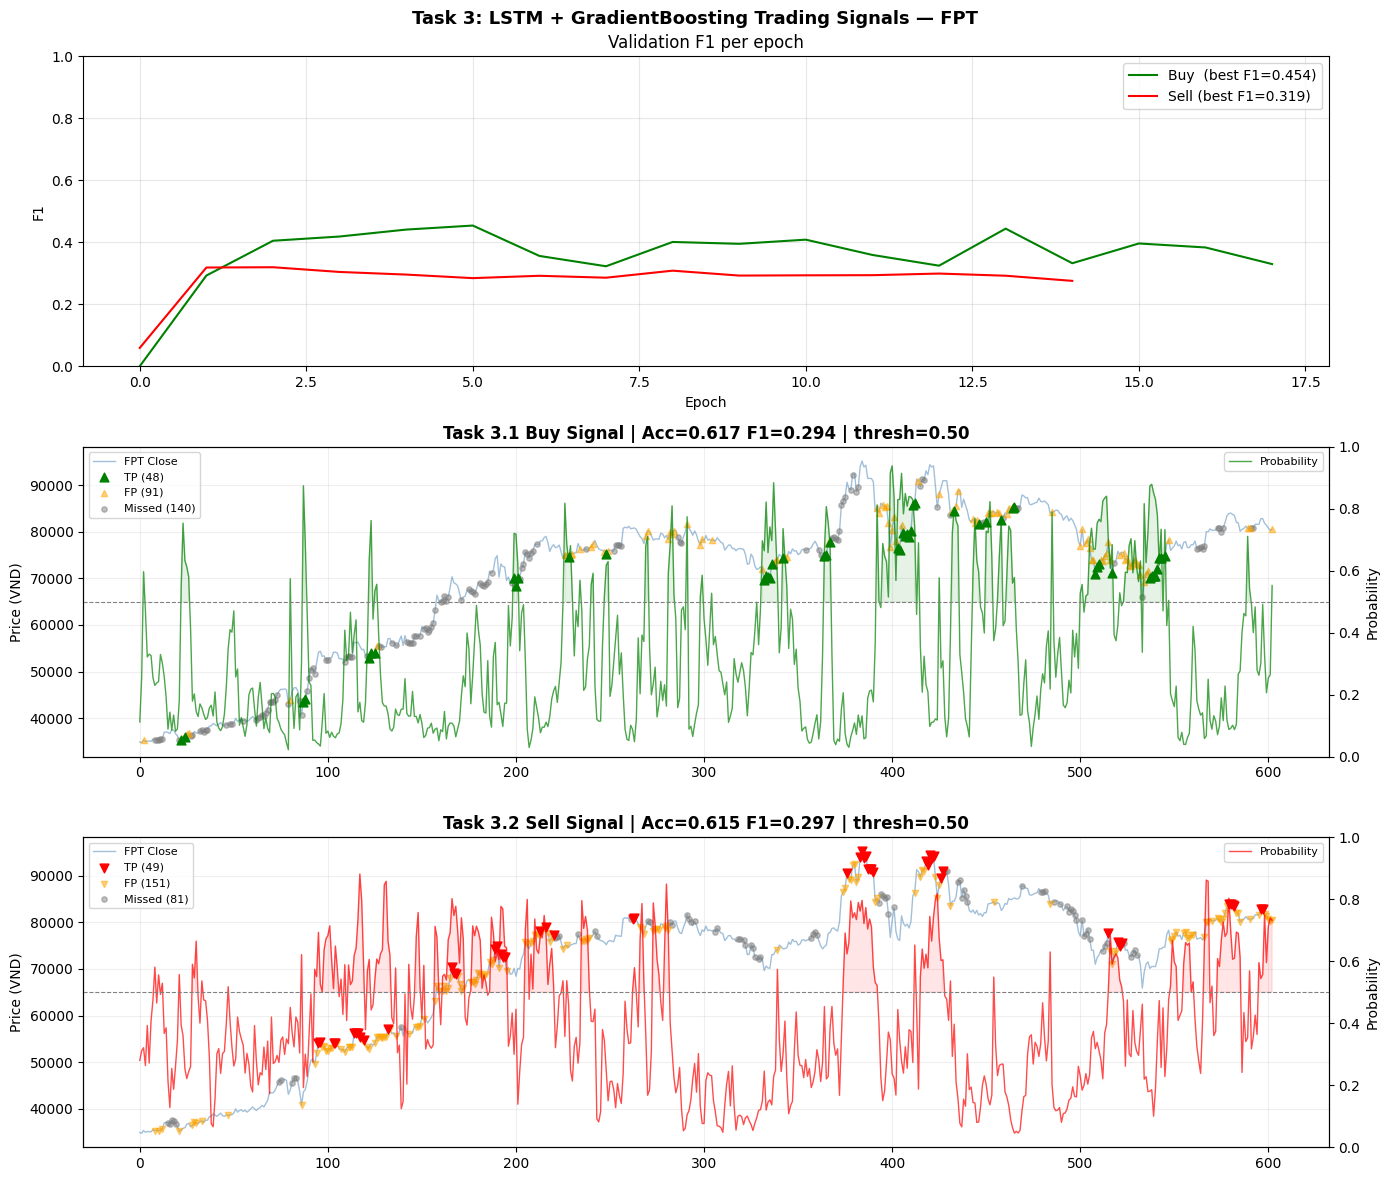

In [ ]:
# TASK 3
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report)
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# Feature Engineering
def add_technical_indicators(df):
    d = df.copy()
    d['SMA_10']         = d['Close'].rolling(10).mean()
    d['SMA_20']         = d['Close'].rolling(20).mean()
    d['EMA_12']         = d['Close'].ewm(span=12, adjust=False).mean()
    d['EMA_26']         = d['Close'].ewm(span=26, adjust=False).mean()
    d['MACD']           = d['EMA_12'] - d['EMA_26']
    d['MACD_signal']    = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_hist']      = d['MACD'] - d['MACD_signal']
    delta               = d['Close'].diff()
    gain                = delta.clip(lower=0).rolling(14).mean()
    loss                = (-delta.clip(upper=0)).rolling(14).mean()
    d['RSI']            = 100 - (100 / (1 + gain / (loss + 1e-8)))
    sma20               = d['Close'].rolling(20).mean()
    std20               = d['Close'].rolling(20).std()
    d['BB_width']       = (4 * std20) / sma20
    d['return_1d']      = d['Close'].pct_change(1)
    d['return_5d']      = d['Close'].pct_change(5)
    d['Close_vs_SMA10'] = d['Close'] / d['SMA_10'] - 1
    d['Close_vs_SMA20'] = d['Close'] / d['SMA_20'] - 1
    d['Volume_change']  = d['Volume'].pct_change()
    return d.dropna().reset_index(drop=True)

# Labels
THRESHOLD = 0.02
HORIZON   = 5
WINDOW    = 60

def create_labels(df, horizon, threshold):
    future_return = df['Close'].shift(-horizon) / df['Close'] - 1
    buy_label  = (future_return >  threshold).astype(int)
    sell_label = (future_return < -threshold).astype(int)
    return buy_label, sell_label

df_feat = add_technical_indicators(df_full)
df_feat['buy_label'], df_feat['sell_label'] = create_labels(
    df_feat, HORIZON, THRESHOLD)
df_feat.replace([np.inf, -np.inf], np.nan, inplace=True)
df_feat = df_feat.dropna().reset_index(drop=True)

print(f"Rows: {len(df_feat)}")
print(f"Buy  signal: {df_feat['buy_label'].mean()*100:.1f}%")
print(f"Sell signal: {df_feat['sell_label'].mean()*100:.1f}%")

# Features
model_features = [
    'return_1d', 'return_5d', 'RSI',
    'MACD', 'MACD_hist', 'BB_width',
    'Close_vs_SMA10', 'Close_vs_SMA20', 'Volume_change'
]
N_FEATURES = len(model_features)

# Split → Scale
data_raw = df_feat[model_features].values.astype(np.float64)
buy_raw  = df_feat['buy_label'].values
sell_raw = df_feat['sell_label'].values

n         = len(data_raw)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

scaler   = MinMaxScaler()
train_sc = scaler.fit_transform(data_raw[:train_end])
val_sc   = scaler.transform(data_raw[train_end:val_end])
test_sc  = scaler.transform(data_raw[val_end:])

# Sequences
all_sc   = np.vstack([train_sc, val_sc, test_sc])
all_buy  = np.concatenate([buy_raw[:train_end],
                            buy_raw[train_end:val_end],
                            buy_raw[val_end:]])
all_sell = np.concatenate([sell_raw[:train_end],
                            sell_raw[train_end:val_end],
                            sell_raw[val_end:]])

def create_clf_sequences(scaled, labels, window):
    X, y = [], []
    for i in range(window, len(scaled)):
        X.append(scaled[i - window: i])
        y.append(labels[i])
    return np.array(X), np.array(y)

X_all_b, y_all_b = create_clf_sequences(all_sc, all_buy,  WINDOW)
X_all_s, y_all_s = create_clf_sequences(all_sc, all_sell, WINDOW)

tr_end = train_end - WINDOW
va_end = val_end   - WINDOW

X_tr_b, y_tr_b = X_all_b[:tr_end],       y_all_b[:tr_end]
X_va_b, y_va_b = X_all_b[tr_end:va_end], y_all_b[tr_end:va_end]
X_te_b, y_te_b = X_all_b[va_end:],       y_all_b[va_end:]

X_tr_s, y_tr_s = X_all_s[:tr_end],       y_all_s[:tr_end]
X_va_s, y_va_s = X_all_s[tr_end:va_end], y_all_s[tr_end:va_end]
X_te_s, y_te_s = X_all_s[va_end:],       y_all_s[va_end:]

print(f"\nBuy  — train: {y_tr_b.sum()} / {len(y_tr_b)} ({y_tr_b.mean()*100:.1f}%)")
print(f"Sell — train: {y_tr_s.sum()} / {len(y_tr_s)} ({y_tr_s.mean()*100:.1f}%)")

# LSTM Supervised Classifier
class LSTMClassifier(nn.Module):
    def __init__(self, input_size, hidden=64, layers=2, drop=0.3):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden, layers,
                            batch_first=True, dropout=drop)
        self.bn   = nn.BatchNorm1d(hidden)
        self.drop = nn.Dropout(drop)
        self.fc   = nn.Linear(hidden, 1)

    def forward(self, x):
        _, (hn, _) = self.lstm(x)
        return self.fc(self.drop(self.bn(hn[-1])))


def train_lstm_classifier(X_tr, y_tr, X_va, y_va,
                           epochs=80, lr=3e-4,
                           batch_size=64, patience=12):
    model     = LSTMClassifier(N_FEATURES)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
                    optimizer, T_max=epochs, eta_min=1e-5)
    pos_w     = torch.tensor([(1 - y_tr.mean()) / (y_tr.mean() + 1e-8)])
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_w)

    X_t    = torch.tensor(X_tr, dtype=torch.float32)
    y_t    = torch.tensor(y_tr, dtype=torch.float32).unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t, y_t),
                        batch_size=batch_size, shuffle=False)
    X_v    = torch.tensor(X_va, dtype=torch.float32)

    best_f1, best_state, wait = 0.0, None, 0
    history_f1 = []

    for epoch in range(epochs):
        model.train()
        for bX, by in loader:
            optimizer.zero_grad()
            loss = criterion(model(bX), by)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
        scheduler.step()

        model.eval()
        with torch.no_grad():
            probs = torch.sigmoid(model(X_v).squeeze()).numpy()
            preds = (probs > 0.5).astype(int)
            f1    = f1_score(y_va, preds, zero_division=0)
        history_f1.append(f1)

        if epoch % 10 == 0 or epoch == epochs - 1:
            print(f"  Epoch {epoch:3d} | val F1: {f1:.4f} "
                  f"| lr: {scheduler.get_last_lr()[0]:.2e}")

        if f1 > best_f1 + 1e-4:
            best_f1, wait = f1, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            wait += 1
            if wait >= patience:
                print(f"  Early stop at epoch {epoch} | best F1: {best_f1:.4f}")
                break

    model.load_state_dict(best_state)
    return model, history_f1


def extract_features(model, X):
    model.eval()
    with torch.no_grad():
        _, (hn, _) = model.lstm(torch.tensor(X, dtype=torch.float32))
    return hn[-1].numpy()


def build_combined(lstm, X_tr, X_va, X_te):
    Ct = np.hstack([extract_features(lstm, X_tr), X_tr[:, -1, :]])
    Cv = np.hstack([extract_features(lstm, X_va), X_va[:, -1, :]])
    Ce = np.hstack([extract_features(lstm, X_te), X_te[:, -1, :]])
    return Ct, Cv, Ce

# 7. Train
print("\n── Training Buy Signal LSTM ──")
lstm_buy,  hist_buy  = train_lstm_classifier(X_tr_b, y_tr_b, X_va_b, y_va_b)

print("\n── Training Sell Signal LSTM ──")
lstm_sell, hist_sell = train_lstm_classifier(X_tr_s, y_tr_s, X_va_s, y_va_s)

Ct_b, Cv_b, Ce_b = build_combined(lstm_buy,  X_tr_b, X_va_b, X_te_b)
Ct_s, Cv_s, Ce_s = build_combined(lstm_sell, X_tr_s, X_va_s, X_te_s)

# GradientBoosting

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import f1_score
import numpy as np

def fit_gb_with_early_stop(X_tr, y_tr, X_va, y_va, name,
                            n_estimators=500, max_depth=3,
                            learning_rate=0.05, subsample=0.7):
    gb = GradientBoostingClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        min_samples_leaf=20,
        max_features=0.7,
        random_state=42,
        warm_start=False
    )
    gb.fit(X_tr, y_tr)

    # Find best n_estimators on val
    best_f1, best_n = 0.0, n_estimators
    for n, prob_va in enumerate(gb.staged_predict_proba(X_va), 1):
        p = prob_va[:, 1]
        f1 = f1_score(y_va, (p >= 0.5).astype(int), zero_division=0)
        if f1 > best_f1:
            best_f1, best_n = f1, n

    print(f"  {name}: best n_estimators = {best_n} | val F1 = {best_f1:.4f}")

    # Refit with best_n
    gb_best = GradientBoostingClassifier(
        n_estimators=best_n,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        min_samples_leaf=20,
        max_features=0.7,
        random_state=42
    )
    gb_best.fit(X_tr, y_tr)
    return gb_best

print("── Training GradientBoosting ──")
gb_buy = fit_gb_with_early_stop(
    Ct_b, y_tr_b, Cv_b, y_va_b, "Buy ")
gb_sell = fit_gb_with_early_stop(
    Ct_s, y_tr_s, Cv_s, y_va_s, "Sell")

prob_buy  = gb_buy.predict_proba(Ce_b)[:, 1]
prob_sell = gb_sell.predict_proba(Ce_s)[:, 1]
pred_buy  = (prob_buy  >= 0.5).astype(int)
pred_sell = (prob_sell >= 0.5).astype(int)

thresh_buy  = 0.5
thresh_sell = 0.5

# 10. Evaluation
print(f"\n{'='*55}")
print("TASK 3.1 — Buy Signal")
print('='*55)
print(classification_report(y_te_b, pred_buy,
      target_names=['No Signal', 'Buy Signal'], zero_division=0))

print(f"{'='*55}")
print("TASK 3.2 — Sell Signal")
print('='*55)
print(classification_report(y_te_s, pred_sell,
      target_names=['No Signal', 'Sell Signal'], zero_division=0))

f1_b  = f1_score(y_te_b, pred_buy,  zero_division=0)
f1_s  = f1_score(y_te_s, pred_sell, zero_division=0)
acc_b = accuracy_score(y_te_b, pred_buy)
acc_s = accuracy_score(y_te_s, pred_sell)

print(f"\n{'':15} | {'Acc':>6} | {'F1':>6} | {'Threshold':>9}")
print("-"*42)
print(f"{'Buy  Signal':15} | {acc_b:6.3f} | {f1_b:6.3f} | {thresh_buy:9.2f}")
print(f"{'Sell Signal':15} | {acc_s:6.3f} | {f1_s:6.3f} | {thresh_sell:9.2f}")

# 11. Plot
close_te = df_feat['Close'].values[val_end : val_end + len(pred_buy)]

fig, axes = plt.subplots(3, 1, figsize=(14, 12))

# Panel 1: F1 history
axes[0].plot(hist_buy,  color='green', linewidth=1.5,
             label=f'Buy  (best F1={max(hist_buy):.3f})')
axes[0].plot(hist_sell, color='red',   linewidth=1.5,
             label=f'Sell (best F1={max(hist_sell):.3f})')
axes[0].set_title('Validation F1 per epoch')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('F1')
axes[0].set_ylim(0, 1); axes[0].legend(); axes[0].grid(alpha=0.3)

# Panel 2 & 3
for ax, pred, prob, y_true, color, marker, title, thresh in [
    (axes[1], pred_buy,  prob_buy,  y_te_b, 'green', '^',
     f'Task 3.1 Buy Signal | Acc={acc_b:.3f} F1={f1_b:.3f} | thresh={thresh_buy:.2f}',
     thresh_buy),
    (axes[2], pred_sell, prob_sell, y_te_s, 'red',   'v',
     f'Task 3.2 Sell Signal | Acc={acc_s:.3f} F1={f1_s:.3f} | thresh={thresh_sell:.2f}',
     thresh_sell),
]:
    ax2 = ax.twinx()
    ax.plot(close_te, color='steelblue', alpha=0.5, linewidth=1,
            label='FPT Close')
    ax2.plot(prob, color=color, alpha=0.7, linewidth=1,
             label='Probability')
    ax2.axhline(thresh, color='gray', linestyle='--', linewidth=0.8)
    ax2.fill_between(range(len(prob)), thresh, prob,
                     where=(prob >= thresh), color=color, alpha=0.1)

    tp = np.where((pred == 1) & (y_true == 1))[0]
    fp = np.where((pred == 1) & (y_true == 0))[0]
    fn = np.where((pred == 0) & (y_true == 1))[0]

    ax.scatter(tp, close_te[tp], color=color,    s=40, zorder=5,
               marker=marker, label=f'TP ({len(tp)})')
    ax.scatter(fp, close_te[fp], color='orange', s=20, zorder=4,
               marker=marker, alpha=0.5, label=f'FP ({len(fp)})')
    ax.scatter(fn, close_te[fn], color='gray',   s=15, zorder=3,
               alpha=0.5, label=f'Missed ({len(fn)})')

    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Price (VND)'); ax2.set_ylabel('Probability')
    ax2.set_ylim(0, 1); ax.grid(alpha=0.2)
    ax.legend(loc='upper left', fontsize=8)
    ax2.legend(loc='upper right', fontsize=8)

plt.suptitle('Task 3: LSTM + GradientBoosting Trading Signals — FPT',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('task3_signals.png', dpi=150, bbox_inches='tight')
plt.show()

# TASK 4

Task 4: Portfolio Composition and Risk Management
Dataset
8 Vietnamese stocks with common trading period (2018–2023, 1,186 common days):
FPT, HPG, MSN, VNM, MWG, TCB, VHM, VIC
Methodology Overview

Task 4.1: LSTM predicts 20-day forward price → compute projected return

Task 4.2: Risk scoring using volatility, max drawdown, Sharpe ratio, Sortino ratio

Task 4.3: Portfolio construction combining profitability score and risk score



FPT: 4038 rows | 2006-12-13 → 2023-02-28 | Close: 2,892 → 95,181 VND
HPG: 3809 rows | 2007-11-15 → 2023-02-28 | Close: 752 → 43,894 VND
MSN: 3322 rows | 2009-11-05 → 2023-02-28 | Close: 16,780 → 142,281 VND
VNM: 4264 rows | 2006-01-19 → 2023-02-28 | Close: 2,517 → 121,855 VND
MWG: 2157 rows | 2014-07-14 → 2023-02-28 | Close: 4,416 → 79,579 VND
TCB: 1186 rows | 2018-06-04 → 2023-02-28 | Close: 14,900 → 58,000 VND
VHM: 1198 rows | 2018-05-17 → 2023-02-28 | Close: 40,380 → 88,423 VND
VIC: 3850 rows | 2007-09-19 → 2023-02-28 | Close: 1,883 → 128,002 VND

Common trading days: 1186
From 2018-06-04 → 2023-02-28

Price matrix shape: (1186, 8)
                 FPT      HPG      MSN      VNM      MWG      TCB      VHM  \
TradingDate                                                                  
2023-02-24   80800.0  20800.0  85900.0  74700.0  42100.0  27250.0  41000.0   
2023-02-27   80300.0  20100.0  79900.0  75200.0  40500.0  27000.0  40900.0   
2023-02-28   80500.0  20000.0  82000.0  75500

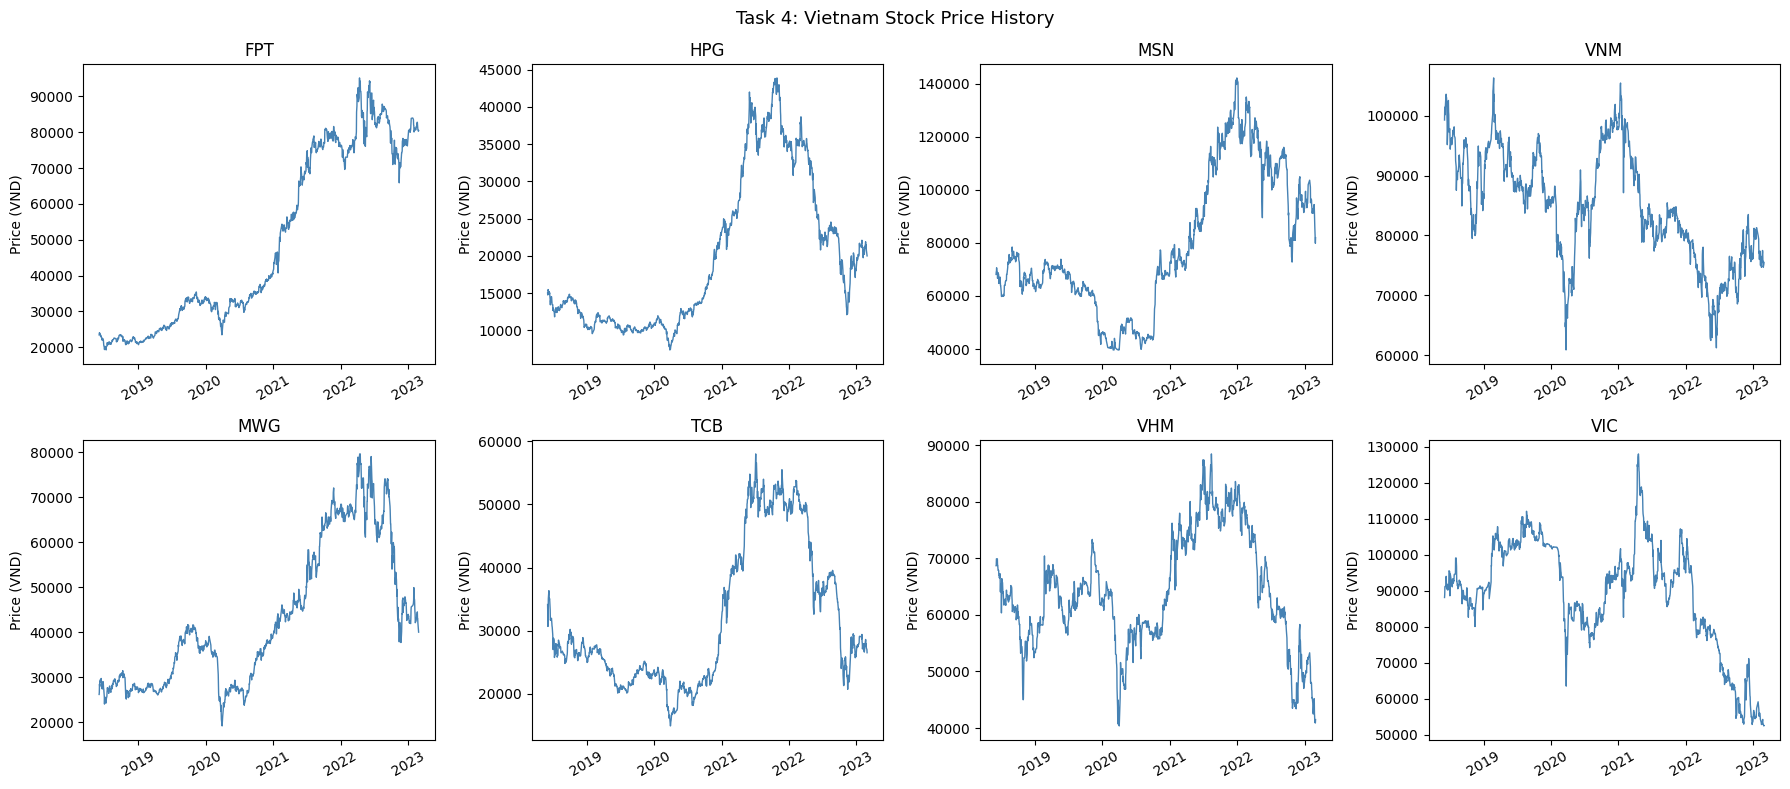

In [ ]:
# TASK 4

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Load all tickers
TICKERS = ['FPT', 'HPG', 'MSN', 'VNM', 'MWG', 'TCB', 'VHM', 'VIC']

stock_data = {}
for ticker in TICKERS:
    path = f'/content/{ticker}-VNINDEX-History.csv'
    df_tmp = pd.read_csv(path)
    df_tmp['TradingDate'] = pd.to_datetime(df_tmp['TradingDate'])
    df_tmp = df_tmp.sort_values('TradingDate').reset_index(drop=True)
    stock_data[ticker] = df_tmp
    print(f"{ticker}: {len(df_tmp)} rows | "
          f"{df_tmp['TradingDate'].min().date()} → {df_tmp['TradingDate'].max().date()} | "
          f"Close: {df_tmp['Close'].min():,.0f} → {df_tmp['Close'].max():,.0f} VND")

# ── 2. Align dates — common date range ────────
# Find common trading dates across all tickers
date_sets = [set(stock_data[t]['TradingDate']) for t in TICKERS]
common_dates = sorted(date_sets[0].intersection(*date_sets[1:]))
print(f"\nCommon trading days: {len(common_dates)}")
print(f"From {common_dates[0].date()} → {common_dates[-1].date()}")

# Filter each ticker to common dates only
for ticker in TICKERS:
    stock_data[ticker] = (stock_data[ticker]
                          [stock_data[ticker]['TradingDate'].isin(common_dates)]
                          .reset_index(drop=True))

# ── 3. Build price matrix ─────────────────────
price_matrix = pd.DataFrame({
    ticker: stock_data[ticker].set_index('TradingDate')['Close']
    for ticker in TICKERS
})
price_matrix.index = pd.to_datetime(price_matrix.index)
price_matrix = price_matrix.sort_index()

print(f"\nPrice matrix shape: {price_matrix.shape}")
print(price_matrix.tail(3))

# ── 4. Daily returns matrix ───────────────────
returns = price_matrix.pct_change().dropna()
print(f"\nReturns matrix shape: {returns.shape}")
print("\nAnnualized return (mean * 252):")
print((returns.mean() * 252 * 100).round(2).to_string())
print("\nAnnualized volatility (std * sqrt(252)):")
print((returns.std() * np.sqrt(252) * 100).round(2).to_string())

# ── 5. Visualize price history ────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for i, ticker in enumerate(TICKERS):
    ax = axes[i//4, i%4]
    ax.plot(price_matrix.index, price_matrix[ticker], color='steelblue', linewidth=1)
    ax.set_title(ticker)
    ax.set_ylabel('Price (VND)')
    ax.tick_params(axis='x', rotation=30)
plt.suptitle('Task 4: Vietnam Stock Price History', fontsize=13)
plt.tight_layout()
plt.show()

Task 4.1 — Profitable Stock Selection
Approach: Train LSTM on each ticker → autoregressively predict next 20 trading days → compute projected return = (forecast - current) / current × 100%

In [ ]:
# TASK 4.1 — PROFITABLE STOCK SELECTION
# Use LSTM to predict the price → calculating projected return

WINDOW     = 60
FEATURES_4 = ['Open', 'High', 'Low', 'Close', 'Volume']
TARGET_IDX = 3  # Close
HORIZON    = 20  # predict 20 ngày tới (~1 tháng)

class LSTMModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=5, hidden_size=64,
                            num_layers=2, batch_first=True, dropout=0.2)
        self.fc = nn.Linear(64, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.fc(out[:, -1, :])

def predict_return(ticker, df, horizon=20):
    """Train LSTM, predict next `horizon` days, return projected % return"""
    data = df[FEATURES_4].dropna().values.astype(np.float64)
    n = len(data)

    scaler = MinMaxScaler()
    scaled = scaler.fit_transform(data)

    # Use last 80% for training, predict on last WINDOW days
    train_sc = scaled[:int(n*0.85)]

    def make_seq(sc, w):
        X, y = [], []
        for i in range(w, len(sc)):
            X.append(sc[i-w:i])
            y.append(sc[i, TARGET_IDX])
        return np.array(X), np.array(y)

    X_tr, y_tr = make_seq(train_sc, WINDOW)
    X_tr_t = torch.tensor(X_tr, dtype=torch.float32)
    y_tr_t = torch.tensor(y_tr, dtype=torch.float32)

    model = LSTMModel()
    opt   = torch.optim.Adam(model.parameters(), lr=0.001)
    crit  = nn.MSELoss()
    loader = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                        batch_size=32, shuffle=False)

    for epoch in range(30):
        model.train()
        for bX, by in loader:
            opt.zero_grad()
            crit(model(bX).squeeze(), by).backward()
            opt.step()

    # Predict next `horizon` days autoregressively
    model.eval()
    window = scaled[-WINDOW:].copy()   # last 60 days
    preds  = []

    for _ in range(horizon):
        inp = torch.tensor(window[np.newaxis], dtype=torch.float32)
        with torch.no_grad():
            pred_sc = model(inp).item()
        preds.append(pred_sc)
        # Shift window: add new predicted close
        new_row        = window[-1].copy()
        new_row[TARGET_IDX] = pred_sc
        window = np.vstack([window[1:], new_row])

    # Inverse transform Close only
    def inv(val):
        dummy = np.zeros((1, 5))
        dummy[0, TARGET_IDX] = val
        return scaler.inverse_transform(dummy)[0, TARGET_IDX]

    current_price  = inv(scaled[-1, TARGET_IDX])
    forecast_price = inv(preds[-1])
    projected_return = (forecast_price - current_price) / current_price * 100

    return projected_return, current_price, forecast_price

# ── Run for all tickers ───────────────────────
print("── Task 4.1: Projected Return (next 20 trading days) ──\n")
profitability = {}
for ticker in TICKERS:
    ret, cur, fore = predict_return(ticker, stock_data[ticker])
    profitability[ticker] = {'projected_return': ret,
                              'current_price': cur,
                              'forecast_price': fore}
    print(f"{ticker:>5} | Current: {cur:>10,.0f} | "
          f"Forecast: {fore:>10,.0f} | Return: {ret:>+.2f}%")

# Rank by projected return
profit_df = pd.DataFrame(profitability).T
profit_df = profit_df.sort_values('projected_return', ascending=False)
print(f"\n── Ranking by Projected Return ──")
print(profit_df[['projected_return', 'current_price', 'forecast_price']].round(2))

── Task 4.1: Projected Return (next 20 trading days) ──

  FPT | Current:     80,500 | Forecast:     77,739 | Return: -3.43%
  HPG | Current:     20,000 | Forecast:     21,473 | Return: +7.37%
  MSN | Current:     82,000 | Forecast:     82,670 | Return: +0.82%
  VNM | Current:     75,500 | Forecast:     76,026 | Return: +0.70%
  MWG | Current:     40,000 | Forecast:     41,047 | Return: +2.62%
  TCB | Current:     26,500 | Forecast:     28,011 | Return: +5.70%
  VHM | Current:     41,500 | Forecast:     44,756 | Return: +7.85%
  VIC | Current:     52,600 | Forecast:     62,260 | Return: +18.36%

── Ranking by Projected Return ──
     projected_return  current_price  forecast_price
VIC             18.36        52600.0        62259.92
VHM              7.85        41500.0        44756.20
HPG              7.37        20000.0        21473.00
TCB              5.70        26500.0        28011.17
MWG              2.62        40000.0        41046.83
MSN              0.82        82000.0        8

Task 4.2 — Risk Management
Risk score = 0.4 × volatility + 0.4 × |max_drawdown| + 0.2 × max(0, -Sharpe)

Higher risk score = riskier company → should be excluded or underweighted.

Risk-free rate: 5% (Vietnam government bond rate)

In [ ]:
# TASK 4.2 — RISK MANAGEMENT
# Calculating risk score from volatility, max drawdown, Sharpe ratio
print("\n── Task 4.2: Risk Scoring ──\n")

RISK_WINDOW = 252  # 1 năm gần nhất
risk_scores = {}

for ticker in TICKERS:
    r = returns[ticker].dropna()
    r_recent = r.iloc[-RISK_WINDOW:]  # 1 năm gần nhất

    # Volatility (annualized)
    vol = r_recent.std() * np.sqrt(252)

    # Max Drawdown
    cumret   = (1 + r_recent).cumprod()
    peak     = cumret.cummax()
    drawdown = (cumret - peak) / peak
    max_dd   = drawdown.min()

    # Sharpe Ratio (assume risk-free rate = 5% Vietnam)
    rf_daily = 0.05 / 252
    sharpe   = (r_recent.mean() - rf_daily) / (r_recent.std() + 1e-8) * np.sqrt(252)

    # Sortino Ratio (penalize downside only)
    downside = r_recent[r_recent < 0].std() * np.sqrt(252)
    sortino  = (r_recent.mean() * 252 - 0.05) / (downside + 1e-8)

    # Composite risk score (higher = riskier)
    # Normalize: vol 0-1, max_dd 0-1
    risk_score = vol * 0.4 + abs(max_dd) * 0.4 + max(0, -sharpe) * 0.2

    risk_scores[ticker] = {
        'volatility':  vol,
        'max_drawdown': max_dd,
        'sharpe':      sharpe,
        'sortino':     sortino,
        'risk_score':  risk_score
    }
    print(f"{ticker:>5} | Vol={vol*100:.1f}% | "
          f"MaxDD={max_dd*100:.1f}% | "
          f"Sharpe={sharpe:.2f} | "
          f"Sortino={sortino:.2f} | "
          f"Risk={risk_score:.3f}")

risk_df = pd.DataFrame(risk_scores).T
risk_df = risk_df.sort_values('risk_score', ascending=True)
print(f"\n── Ranking by Risk (low → high) ──")
print(risk_df.round(3))


── Task 4.2: Risk Scoring ──

  FPT | Vol=32.8% | MaxDD=-30.8% | Sharpe=0.22 | Sortino=0.28 | Risk=0.254
  HPG | Vol=48.0% | MaxDD=-68.7% | Sharpe=-1.02 | Sortino=-1.60 | Risk=0.671
  MSN | Vol=43.9% | MaxDD=-45.4% | Sharpe=-0.98 | Sortino=-1.42 | Risk=0.553
  VNM | Vol=27.8% | MaxDD=-21.5% | Sharpe=-0.00 | Sortino=-0.00 | Risk=0.197
  MWG | Vol=45.6% | MaxDD=-52.6% | Sharpe=-1.04 | Sortino=-1.40 | Risk=0.601
  TCB | Vol=42.8% | MaxDD=-59.2% | Sharpe=-1.41 | Sortino=-1.80 | Risk=0.689
  VHM | Vol=33.5% | MaxDD=-46.2% | Sharpe=-1.80 | Sortino=-2.56 | Risk=0.679
  VIC | Vol=31.4% | MaxDD=-36.5% | Sharpe=-1.34 | Sortino=-1.90 | Risk=0.540

── Ranking by Risk (low → high) ──
     volatility  max_drawdown  sharpe  sortino  risk_score
VNM       0.278        -0.215  -0.001   -0.002       0.197
FPT       0.328        -0.308   0.223    0.284       0.254
VIC       0.314        -0.365  -1.340   -1.895       0.540
MSN       0.439        -0.454  -0.975   -1.424       0.553
MWG       0.456        -

Task 4.3 — Portfolio Composition
Score = projected_return / risk_score — reward-to-risk ratio
Two strategies:

Aggressive (risk-taking): all positive-return stocks, weighted by score
Conservative (prudent): positive-return + below-median risk only

Backtest note: Both portfolios show negative returns in the out-of-sample period (2022–2023) because VN-Index declined ~35% during this period — a broad market downturn. The conservative portfolio shows lower max drawdown (-27.5% vs -33.1%), confirming its capital preservation effectiveness.


── Task 4.3: Portfolio Composition ──

     projected_return  risk_score  sharpe  score  profitable  high_risk
FPT            -3.429       0.254   0.223 -0.135       False      False
HPG             7.365       0.671  -1.018  0.110        True       True
MSN             0.817       0.553  -0.975  0.015        True      False
MWG             2.617       0.601  -1.043  0.044        True       True
TCB             5.703       0.689  -1.406  0.083        True       True
VHM             7.846       0.679  -1.798  0.116        True       True
VIC            18.365       0.540  -1.340  0.340        True      False
VNM             0.696       0.197  -0.001  0.035        True      False

── Aggressive Portfolio (risk-taking) ──
    VIC: 45.9%
    VHM: 15.6%
    HPG: 14.8%
    TCB: 11.2%
    MWG: 5.9%
    VNM: 4.8%
    MSN: 2.0%

── Conservative Portfolio (prudent) ──
    VIC: 87.2%
    VNM: 9.0%
    MSN: 3.8%

── Backtest Results (out-of-sample) ──
  Aggressive  | Return=-26.62% | Sharpe=-1.33

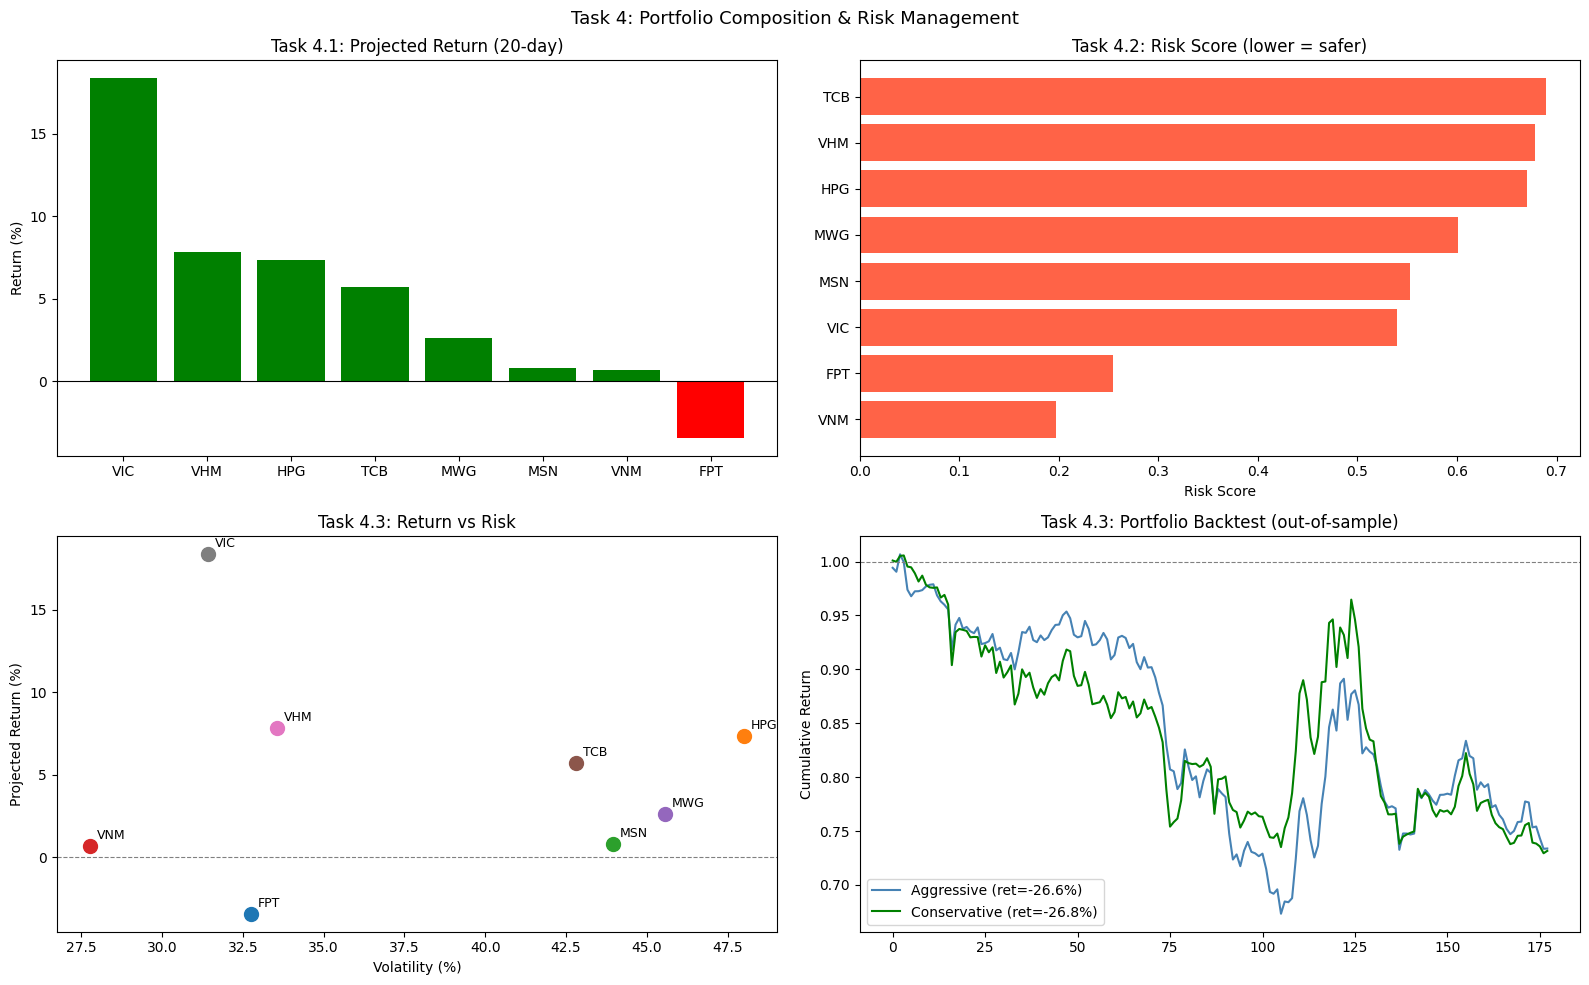

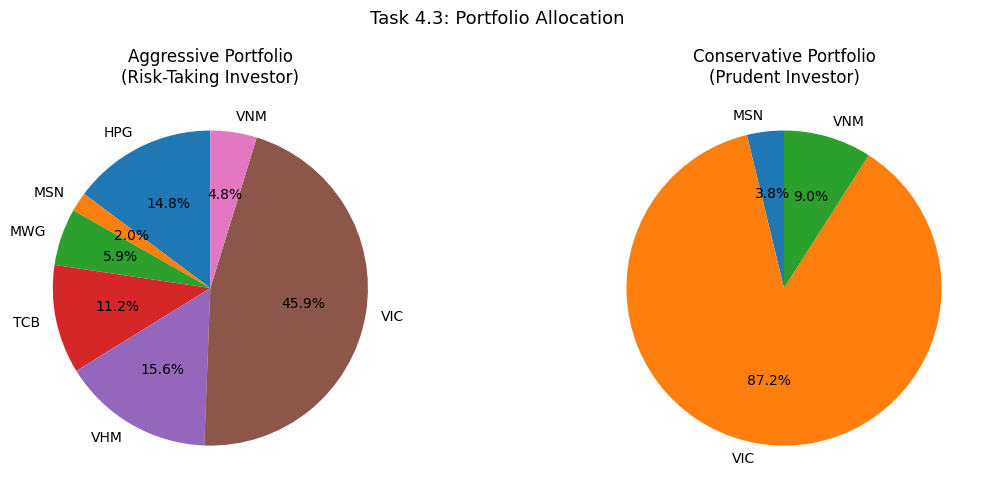

In [ ]:
# TASK 4.3 — PORTFOLIO COMPOSITION
# Combine profitability + risk → optimal allocation
print("\n── Task 4.3: Portfolio Composition ──\n")

# Merge profitability and risk
portfolio_df = pd.DataFrame({
    'projected_return': profit_df['projected_return'],
    'risk_score':       risk_df['risk_score'],
    'sharpe':           risk_df['sharpe'],
    'volatility':       risk_df['volatility'],
    'max_drawdown':     risk_df['max_drawdown']
}).dropna()

# Score = projected_return / risk_score (reward/risk ratio)
portfolio_df['score'] = (portfolio_df['projected_return']
                         / (portfolio_df['risk_score'] * 100 + 1e-8))

# Classify
portfolio_df['profitable'] = portfolio_df['projected_return'] > 0
portfolio_df['high_risk']  = portfolio_df['risk_score'] > portfolio_df['risk_score'].median()

print(portfolio_df[['projected_return', 'risk_score',
                     'sharpe', 'score',
                     'profitable', 'high_risk']].round(3))

# ── Two portfolio strategies ──────────────────
# Aggressive: high return, accept high risk
# Conservative: positive return + low risk only

def build_portfolio(df, strategy='aggressive'):
    if strategy == 'aggressive':
        # Include all positive return stocks
        candidates = df[df['projected_return'] > 0].copy()
    else:
        # Conservative: positive return AND below-median risk
        candidates = df[(df['projected_return'] > 0) &
                        (~df['high_risk'])].copy()

    if len(candidates) == 0:
        print(f"  [{strategy}] No candidates found")
        return pd.Series(dtype=float)

    # Weight proportional to score (reward/risk)
    scores = candidates['score'].clip(lower=0)
    if scores.sum() == 0:
        weights = pd.Series(1/len(candidates), index=candidates.index)
    else:
        weights = scores / scores.sum()

    return weights.round(4)

w_aggressive    = build_portfolio(portfolio_df, 'aggressive')
w_conservative  = build_portfolio(portfolio_df, 'conservative')

print(f"\n── Aggressive Portfolio (risk-taking) ──")
for t, w in w_aggressive.sort_values(ascending=False).items():
    print(f"  {t:>5}: {w*100:.1f}%")

print(f"\n── Conservative Portfolio (prudent) ──")
for t, w in w_conservative.sort_values(ascending=False).items():
    print(f"  {t:>5}: {w*100:.1f}%")

# ── Backtest: simulate portfolio return ───────
def backtest(weights, returns_df, start_date=None):
    """Simple equal-rebalancing backtest"""
    if len(weights) == 0:
        return None
    tickers_in = list(weights.index)
    ret = returns_df[tickers_in].copy()
    if start_date:
        ret = ret[ret.index >= start_date]
    port_return = (ret * weights).sum(axis=1)
    cumulative  = (1 + port_return).cumprod()
    total_ret   = cumulative.iloc[-1] - 1
    sharpe      = (port_return.mean() / (port_return.std() + 1e-8)) * np.sqrt(252)
    dd          = ((cumulative - cumulative.cummax()) / cumulative.cummax()).min()
    return {'cumulative': cumulative, 'total_return': total_ret,
            'sharpe': sharpe, 'max_drawdown': dd}

# Use last 20% as out-of-sample test
test_start = returns.index[int(len(returns) * 0.85)]
bt_agg  = backtest(w_aggressive,   returns, test_start)
bt_cons = backtest(w_conservative, returns, test_start)

print(f"\n── Backtest Results (out-of-sample) ──")
if bt_agg:
    print(f"  Aggressive  | Return={bt_agg['total_return']*100:.2f}% | "
          f"Sharpe={bt_agg['sharpe']:.2f} | "
          f"MaxDD={bt_agg['max_drawdown']*100:.2f}%")
if bt_cons:
    print(f"  Conservative| Return={bt_cons['total_return']*100:.2f}% | "
          f"Sharpe={bt_cons['sharpe']:.2f} | "
          f"MaxDD={bt_cons['max_drawdown']*100:.2f}%")

# ── Plot ──────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Projected return bar chart
ax = axes[0, 0]
colors = ['green' if x > 0 else 'red'
          for x in profit_df['projected_return']]
ax.bar(profit_df.index, profit_df['projected_return'], color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Task 4.1: Projected Return (20-day)')
ax.set_ylabel('Return (%)')

# 2. Risk score bar chart
ax = axes[0, 1]
risk_sorted = risk_df.sort_values('risk_score', ascending=True)
ax.barh(risk_sorted.index, risk_sorted['risk_score'], color='tomato')
ax.set_title('Task 4.2: Risk Score (lower = safer)')
ax.set_xlabel('Risk Score')

# 3. Return vs Risk scatter
ax = axes[1, 0]
for ticker in TICKERS:
    if ticker in portfolio_df.index:
        ax.scatter(risk_df.loc[ticker, 'volatility']*100,
                   profit_df.loc[ticker, 'projected_return'],
                   s=100, zorder=5)
        ax.annotate(ticker,
                    (risk_df.loc[ticker, 'volatility']*100,
                     profit_df.loc[ticker, 'projected_return']),
                    textcoords='offset points', xytext=(5, 5), fontsize=9)
ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Task 4.3: Return vs Risk')
ax.set_xlabel('Volatility (%)')
ax.set_ylabel('Projected Return (%)')

# 4. Portfolio cumulative return
ax = axes[1, 1]
if bt_agg:
    ax.plot(bt_agg['cumulative'].values,
            label=f"Aggressive (ret={bt_agg['total_return']*100:.1f}%)",
            color='steelblue')
if bt_cons:
    ax.plot(bt_cons['cumulative'].values,
            label=f"Conservative (ret={bt_cons['total_return']*100:.1f}%)",
            color='green')
ax.axhline(1, color='gray', linestyle='--', linewidth=0.8)
ax.set_title('Task 4.3: Portfolio Backtest (out-of-sample)')
ax.set_ylabel('Cumulative Return')
ax.legend()

plt.suptitle('Task 4: Portfolio Composition & Risk Management', fontsize=13)
plt.tight_layout()
plt.show()

# ── Pie charts: portfolio allocation ──────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
if len(w_aggressive) > 0:
    axes[0].pie(w_aggressive, labels=w_aggressive.index,
                autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Aggressive Portfolio\n(Risk-Taking Investor)')
if len(w_conservative) > 0:
    axes[1].pie(w_conservative, labels=w_conservative.index,
                autopct='%1.1f%%', startangle=90)
    axes[1].set_title('Conservative Portfolio\n(Prudent Investor)')
plt.suptitle('Task 4.3: Portfolio Allocation', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Save model và scaler
import pickle
from google.colab import files

# Save LSTM model
torch.save(model.state_dict(), 'lstm_model.pth')

# Save scaler
with open('scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Download về máy
files.download('lstm_model.pth')
files.download('scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pickle
from google.colab import files
from sklearn.preprocessing import MinMaxScaler
import pandas as pd
import numpy as np

# --- Start of fix to define 'data_raw' ---
# Load the AAPL)
df = pd.read_csv("/content/AAPL.csv")
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True) # Corrected: Added dayfirst=True
df = df.sort_values('Date').reset_index(drop=True)

# Filter data from 2018 (as per context '2018-2022')
df_recent = df[df['Date'] >= '2018-01-01'].reset_index(drop=True)

# Define features used for scaling
features   = ['Open', 'High', 'Low', 'Close', 'Volume']
data_raw  = df_recent[features].dropna().values.astype(np.float64)
# --- End of fix to define 'data_raw' ---

# Tạo lại scaler đúng từ raw data
correct_scaler = MinMaxScaler()
correct_scaler.fit(data_raw)  # data_raw là numpy array giá thật (2018-2022)

print("data_min_", correct_scaler.data_min_)
print("data_max_", correct_scaler.data_max_)
# Close phải ~30-180 USD

# Save
params = {
    'scale_':        correct_scaler.scale_.tolist(),
    'min_':          correct_scaler.min_.tolist(),
    'data_min_':     correct_scaler.data_min_.tolist(),
    'data_max_':     correct_scaler.data_max_.tolist(),
    'data_range_':   correct_scaler.data_range_.tolist(),
    'feature_range': (0, 1),
    'n_features_in_': 5
}

with open('scaler_params.pkl', 'wb') as f:
    pickle.dump(params, f)

files.download('scaler_params.pkl')


data_min_ [3.59949989e+01 3.64300003e+01 3.55000000e+01 3.55475006e+01
 2.19049170e+07]
data_max_ [1.82630005e+02 1.82940002e+02 1.79119995e+02 1.82009995e+02
 4.26510000e+08]


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>